<a href="https://colab.research.google.com/github/bctcaiedu/milaisw/blob/main/2026_%EC%9C%A1%EA%B5%B0_AI%EC%86%8C%EC%96%91%EA%B5%90%EC%9C%A1_4%EC%9D%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎖️ 2026년 부대 맞춤형 AI·SW 소양교육
## 육군 직무보수교육 - **4일차 미니 프로젝트**

> **Ⅳ. 부대 실무 데이터를 활용한 EDA 및 시각화**

### 🎯 프로젝트 주제
> **"부대 장비 정비 기록 분석을 통한 예방정비 전략 수립"**

### 📚 오늘 배울 내용
- **EDA(탐색적 데이터 분석)** 개념 및 6단계 프로세스
- 부대 장비 정비 데이터 로드 & 품질 점검
- 기술통계 분석 (describe, value_counts)
- 단변량 분석 (히스토그램, 박스플롯)
- 다변량 분석 (groupby, corr, heatmap)
- 차트 선택 가이드 (6가지 차트 유형)
- **인사이트 도출 및 보고서 작성**

---

### 💡 John Tukey의 EDA 정의 (1977)
> **"데이터가 우리에게 무엇을 말하는지 먼저 들어라."**  
> 데이터를 분석하기 전, 그래프·통계로 **구조·패턴·이상치·관계**를 직관적으로 파악하는 탐색 과정

### 🏛 부대 현장 활용 사례
- **🔧 장비 정비**: 고장 빈도·정비소요시간 분석 → 예방정비 시기 예측
- **🎯 훈련 성과**: 사격·체력검정 결과 분포 및 추세 파악
- **📦 군수 현황**: 물자 소비 패턴 분석 → 적정 재고 수준 도출

---

# 🛠️ Chapter 0. 환경 구성 및 실습 데이터 준비

## 0-1. 라이브러리 import

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"seaborn   : {sns.__version__}")

pandas    : 2.2.2
numpy     : 2.0.2
seaborn   : 0.13.2


## 0-2. 한글 폰트 설정

In [59]:
!apt-get install -qq fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
sns.set_style('whitegrid')
sns.set_context('notebook')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print("✅ 한글 폰트 설정 완료")

✅ 한글 폰트 설정 완료


## 0-3. 실습 데이터 생성 — 부대 장비 정비 기록

PPT에서 제시된 시나리오(240건 × 10컬럼 × 12개월)를 그대로 재현합니다.

**데이터 명세**
- 기간: 2024년 1월 ~ 2024년 12월 (12개월)
- 장비유형 4종: K131 트럭, K200 장갑차, 발전기, K511 카고트럭
- 고장유형 5종: 엔진 이상, 변속기 결함, 브레이크 마모, 궤도 마모, 오일 누유
- 의도적 삽입:
  - 결측값 (정비일자 2건, 고장유형 5건)
  - 이상치 (정비시간 38.5h 초과)
  - 계절성 (8월 훈련 후 급증)

In [17]:
np.random.seed(42)
N = 240

# 장비유형별 특성 (정비시간 평균, 비용 평균)
equip_specs = {
    "K131 트럭":   {"time_mean": 6.0,  "cost_mean": 100, "weight": 0.30, "code": "K131"},
    "K200 장갑차": {"time_mean": 18.0, "cost_mean": 480, "weight": 0.25, "code": "K200"},
    "K511 카고":   {"time_mean": 8.0,  "cost_mean": 150, "weight": 0.25, "code": "K511"},
    "발전기":      {"time_mean": 4.0,  "cost_mean": 85,  "weight": 0.20, "code": "GEN"},
}

equip_types = list(equip_specs.keys())
weights     = [equip_specs[e]["weight"] for e in equip_types]

breakdown_types = ["엔진 이상", "변속기 결함", "브레이크 마모", "궤도 마모", "오일 누유"]
units   = ["1중대", "2중대", "3중대", "4중대"]
results = ["완료", "부분완료", "가동불능"]

# 날짜 생성 - 8월에 정비 건수 몰리도록 (하계 훈련 후)
month_weights = [0.06, 0.06, 0.07, 0.08, 0.08, 0.09, 0.09, 0.15, 0.10, 0.08, 0.07, 0.07]
month_weights = np.array(month_weights) / sum(month_weights)
months = np.random.choice(range(1, 13), size=N, p=month_weights)

dates = []
for m in months:
    d = np.random.randint(1, 29)
    dates.append(f"2024-{m:02d}-{d:02d}")

# 장비유형 배정
types = np.random.choice(equip_types, N, p=weights)

# 장비번호: 코드-번호 (K131-003 형식)
equip_ids = [f"{equip_specs[t]['code']}-{np.random.randint(1, 30):03d}" for t in types]

# 정비시간: 장비유형에 따라 다른 평균, 일부 이상치
times = []
for t in types:
    base = equip_specs[t]["time_mean"]
    # 5% 확률로 이상치 (아주 긴 정비)
    if np.random.random() < 0.05:
        times.append(np.round(np.random.uniform(38, 48), 1))
    else:
        times.append(np.round(max(0.5, np.random.gamma(2.5, base/2.5)), 1))

# 정비비용: 정비시간과 강한 양의 상관 + 장비별 가중치
costs = []
for t, time in zip(types, times):
    cost_base = equip_specs[t]["cost_mean"]
    cost = cost_base * (time / equip_specs[t]["time_mean"]) * np.random.uniform(0.7, 1.3)
    costs.append(int(max(12, cost)))

# 고장유형 - 장비별 특성 반영
breakdowns = []
for t in types:
    if t == "K200 장갑차":
        bd = np.random.choice(["변속기 결함", "궤도 마모", "엔진 이상"], p=[0.4, 0.4, 0.2])
    elif t == "발전기":
        bd = np.random.choice(["엔진 이상", "오일 누유"], p=[0.6, 0.4])
    else:
        bd = np.random.choice(breakdown_types)
    breakdowns.append(bd)

# 정비 결과
result_list = np.random.choice(results, N, p=[0.80, 0.12, 0.08])

# DataFrame 생성
df_raw = pd.DataFrame({
    "정비일자": dates,
    "장비번호": equip_ids,
    "장비유형": types,
    "고장유형": breakdowns,
    "담당부대": np.random.choice(units, N),
    "정비시간(h)": times,
    "정비비용(만원)": costs,
    "결과": result_list,
})

# 의도적으로 결측값 삽입
df_raw.loc[[13, 87], "정비일자"] = np.nan                          # 2건
df_raw.loc[[5, 40, 100, 150, 200], "고장유형"] = np.nan            # 5건

# 저장
df_raw.to_csv('/content/maintenance_log.csv', index=False, encoding='utf-8-sig')

# from google.colab import drive
# drive.mount('/content/drive')
# df_raw.to_csv('/content/drive/MyDrive/maintenance_log.csv', index=False, encoding='utf-8-sig')


print(f"✅ 정비 기록 생성: {df_raw.shape[0]}건 × {df_raw.shape[1]}컬럼")
print(f"   기간        : 2024년 1월 ~ 12월")
print(f"   장비유형    : {df_raw['장비유형'].nunique()}종")
print(f"   결측값      : 정비일자 2건, 고장유형 5건 (의도적 삽입)")
print(f"   저장 위치   : /content/maintenance_log.csv")
df_raw.head()

✅ 정비 기록 생성: 240건 × 8컬럼
   기간        : 2024년 1월 ~ 12월
   장비유형    : 4종
   결측값      : 정비일자 2건, 고장유형 5건 (의도적 삽입)
   저장 위치   : /content/maintenance_log.csv


,정비일자,장비번호,장비유형,고장유형,담당부대,정비시간(h),정비비용(만원),결과
0,2024-06-28,GEN-022,발전기,오일 누유,2중대,6.3,132,가동불능
1,2024-12-14,K511-014,K511 카고,엔진 이상,2중대,7.3,162,완료
2,2024-09-21,GEN-026,발전기,오일 누유,1중대,8.4,183,완료
3,2024-08-06,K131-028,K131 트럭,궤도 마모,3중대,6.8,82,부분완료
4,2024-03-03,K131-023,K131 트럭,오일 누유,1중대,11.2,201,완료


---
# 📚 Chapter 1. EDA 개념과 6단계 프로세스

## 1-1. EDA란 무엇인가?

### 존 튜키(John Tukey)의 정의 — 1977
> 데이터를 분석하기 전, **그래프·통계 방법**으로  
> 데이터의 **구조·패턴·이상치·관계**를 직관적으로 파악하는 **탐색 과정**

### EDA가 중요한 4가지 이유

| 목적 | 설명 |
|---|---|
| 🧐 **품질 문제 발견** | 결측값·오류·이상치 사전 탐지 |
| 🎯 **분석 방향 설정** | 모델링 전 적합한 전략 수립 |
| 💡 **패턴·인사이트** | 예상치 못한 발견 |
| 📣 **시각적 전달** | 비전문가에게도 쉽게 설명 |

## 1-2. EDA 6단계 프로세스

```
┌─────────────────────────────────────────────────────┐
│ ① 데이터 로드      │ df.info() / df.shape           │
│ ② 품질 점검        │ isnull() / duplicated()        │
│ ③ 기술통계 분석    │ describe() / value_counts()    │
│ ④ 단변량 분석      │ hist() / boxplot()             │
│ ⑤ 다변량 분석      │ corr() / groupby() / heatmap   │
│ ⑥ 인사이트 도출    │ 의사결정 권고안 작성            │
└─────────────────────────────────────────────────────┘
```

오늘은 이 6단계를 **부대 장비 정비 데이터** 로 직접 실행해 봅니다.

---
### 🔥 실습문제 1 - EDA 개념 확인
다음 질문에 답하세요.

1. EDA라는 개념을 처음 제시한 통계학자의 이름은?
2. EDA 6단계 중 `describe()`가 사용되는 단계는 몇 단계?
3. 아래 상황에 적합한 EDA 단계를 매칭하세요.
   - (a) "정비시간 평균과 표준편차를 알고 싶다"
   - (b) "정비시간과 정비비용이 관련 있을까?"
   - (c) "결측값이 몇 건 있는지 확인"


In [18]:
# ✍️ 여기에 답을 작성하세요

answer_1 = ""        # 이름
answer_2 = 0         # 숫자
match_a = 0          # 1~6 중 해당 단계
match_b = 0
match_c = 0

print(f"1) EDA 창시자: {answer_1}")
print(f"2) describe() 단계: {answer_2}")
print(f"3-a) 평균·표준편차 분석 → {match_a}단계")
print(f"3-b) 변수 간 관련성 → {match_b}단계")
print(f"3-c) 결측값 확인 → {match_c}단계")

1) EDA 창시자: 
2) describe() 단계: 0
3-a) 평균·표준편차 분석 → 0단계
3-b) 변수 간 관련성 → 0단계
3-c) 결측값 확인 → 0단계


**✅ 정답**

In [19]:
answer_1 = "John Tukey (존 튜키)"
answer_2 = 3
match_a  = 3       # 기술통계 분석
match_b  = 5       # 다변량 분석
match_c  = 2       # 품질 점검

print(f"1) EDA 창시자: {answer_1}")
print(f"2) describe() 단계: {answer_2}단계 (기술통계 분석)")
print(f"3-a) 평균·표준편차 → {match_a}단계 (기술통계 분석)")
print(f"3-b) 변수 간 관련성 → {match_b}단계 (다변량 분석)")
print(f"3-c) 결측값 확인 → {match_c}단계 (품질 점검)")

1) EDA 창시자: John Tukey (존 튜키)
2) describe() 단계: 3단계 (기술통계 분석)
3-a) 평균·표준편차 → 3단계 (기술통계 분석)
3-b) 변수 간 관련성 → 5단계 (다변량 분석)
3-c) 결측값 확인 → 2단계 (품질 점검)


---
# 📥 Chapter 2. [Step 1-2] 데이터 로드 & 품질 점검

## 2-1. 데이터 로드

In [20]:
# CSV 파일 읽기
df = pd.read_csv('/content/maintenance_log.csv', encoding='utf-8-sig')

# 기본 정보 확인
print(f"📊 데이터 크기: {df.shape[0]}건 × {df.shape[1]}컬럼\n")
print(f"📋 컬럼 목록: {df.columns.tolist()}\n")
print(f"📝 상위 5건 미리보기:")
df.head()

📊 데이터 크기: 240건 × 8컬럼

📋 컬럼 목록: ['정비일자', '장비번호', '장비유형', '고장유형', '담당부대', '정비시간(h)', '정비비용(만원)', '결과']

📝 상위 5건 미리보기:


,정비일자,장비번호,장비유형,고장유형,담당부대,정비시간(h),정비비용(만원),결과
0,2024-06-28,GEN-022,발전기,오일 누유,2중대,6.3,132,가동불능
1,2024-12-14,K511-014,K511 카고,엔진 이상,2중대,7.3,162,완료
2,2024-09-21,GEN-026,발전기,오일 누유,1중대,8.4,183,완료
3,2024-08-06,K131-028,K131 트럭,궤도 마모,3중대,6.8,82,부분완료
4,2024-03-03,K131-023,K131 트럭,오일 누유,1중대,11.2,201,완료


In [21]:
# 데이터 구조 한눈에 보기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   정비일자      238 non-null    object 
 1   장비번호      240 non-null    object 
 2   장비유형      240 non-null    object 
 3   고장유형      235 non-null    object 
 4   담당부대      240 non-null    object 
 5   정비시간(h)   240 non-null    float64
 6   정비비용(만원)  240 non-null    int64  
 7   결과        240 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 15.1+ KB


## 2-2. 데이터 품질 점검 — 결측값 확인

In [22]:
# 컬럼별 결측값 개수
missing = df.isnull().sum()
print("[ 컬럼별 결측값 ]")
print(missing[missing > 0])

# 결측 비율
print(f"\n[ 결측 비율(%) ]")
pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pct[pct > 0])

[ 컬럼별 결측값 ]
정비일자    2
고장유형    5
dtype: int64

[ 결측 비율(%) ]
정비일자    0.83
고장유형    2.08
dtype: float64


In [23]:
# 중복 행 확인
dup_count = df.duplicated().sum()
print(f"🔍 중복 행 수: {dup_count}건")

# 결측값이 있는 행 직접 보기
print(f"\n[ 정비일자 결측 행 ]")
print(df[df['정비일자'].isnull()])

🔍 중복 행 수: 0건

[ 정비일자 결측 행 ]
   정비일자      장비번호     장비유형     고장유형 담당부대  정비시간(h)  정비비용(만원)  결과
13  NaN   GEN-019      발전기    오일 누유  1중대      4.0       102  완료
87  NaN  K131-024  K131 트럭  브레이크 마모  1중대      2.6        47  완료


## 2-3. 결측값 처리 전략

| 컬럼 | 결측 건수 | 전략 | 이유 |
|---|---|---|---|
| 정비일자 | 2건 | **행 삭제** | 날짜 없으면 시계열 분석 불가 |
| 고장유형 | 5건 | **'미확인' 대체** | 정비 기록은 존재, 가치 있음 |

In [24]:
# ① 정비일자 결측 → 행 삭제
before = len(df)
df = df.dropna(subset=['정비일자']).reset_index(drop=True)
print(f"✅ 정비일자 결측 제거: {before} → {len(df)}건")

# ② 고장유형 결측 → '미확인'
df['고장유형'] = df['고장유형'].fillna('미확인')
print(f"✅ 고장유형 결측 처리: '미확인'으로 대체")

# ③ 최종 결측 확인
print(f"\n[ 처리 후 결측값 ]")
final_missing = df.isnull().sum()
print(final_missing[final_missing > 0] if final_missing.sum() > 0 else "✅ 결측값 없음")

✅ 정비일자 결측 제거: 240 → 238건
✅ 고장유형 결측 처리: '미확인'으로 대체

[ 처리 후 결측값 ]
✅ 결측값 없음


## 2-4. 날짜 변환 + 파생변수 생성

In [25]:
# 문자열 → datetime 변환
df['정비일자'] = pd.to_datetime(df['정비일자'])

# 파생변수 생성
df['월']   = df['정비일자'].dt.month
df['분기'] = df['정비일자'].dt.quarter
df['요일'] = df['정비일자'].dt.day_name()

# 한글 요일 매핑
weekday_kr = {'Monday':'월','Tuesday':'화','Wednesday':'수',
              'Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}
df['요일_한글'] = df['요일'].map(weekday_kr)

print("[ 파생변수 생성 완료 ]")
df[['정비일자', '월', '분기', '요일_한글']].head()

[ 파생변수 생성 완료 ]


,정비일자,월,분기,요일_한글
0,2024-06-28,6,2,금
1,2024-12-14,12,4,토
2,2024-09-21,9,3,토
3,2024-08-06,8,3,화
4,2024-03-03,3,1,일


---
### 🔥 실습문제 2
1. `df`의 **컬럼별 자료형(dtype)** 을 한 줄로 출력
2. `"결과"` 컬럼의 **고유값** 과 각 값의 **개수** 를 출력
3. `"담당부대"` 별로 **정비 기록 수** 를 내림차순으로 출력
4. 정비일자가 **2024-08-01 ~ 2024-08-31** 인 데이터의 **건수** 를 계산

In [26]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [27]:
# 1) 컬럼별 자료형
print("[ 1. 컬럼별 자료형 ]")
print(df.dtypes)

# 2) 결과 고유값 & 개수
print("\n[ 2. 결과 분포 ]")
print(df['결과'].value_counts())

# 3) 담당부대별 기록 수
print("\n[ 3. 담당부대별 정비 건수 ]")
print(df['담당부대'].value_counts())

# 4) 8월 건수
aug = df[(df['정비일자'] >= '2024-08-01') & (df['정비일자'] <= '2024-08-31')]
print(f"\n[ 4. 2024년 8월 정비 건수: {len(aug)}건 ]")

[ 1. 컬럼별 자료형 ]
정비일자        datetime64[ns]
장비번호                object
장비유형                object
고장유형                object
담당부대                object
정비시간(h)            float64
정비비용(만원)             int64
결과                  object
월                    int32
분기                   int32
요일                  object
요일_한글               object
dtype: object

[ 2. 결과 분포 ]
결과
완료      189
부분완료     31
가동불능     18
Name: count, dtype: int64

[ 3. 담당부대별 정비 건수 ]
담당부대
1중대    74
4중대    56
3중대    55
2중대    53
Name: count, dtype: int64

[ 4. 2024년 8월 정비 건수: 36건 ]


---
# 📊 Chapter 3. [Step 3] 기술통계 분석

## 3-1. `describe()` — 수치형 전체 요약

In [28]:
# 수치형 통계 요약
summary = df[['정비시간(h)', '정비비용(만원)']].describe().round(2)
print("[ 정비시간·비용 기술통계 ]")
print(summary)

[ 정비시간·비용 기술통계 ]
       정비시간(h)  정비비용(만원)
count   238.00    238.00
mean     12.15    264.82
std      12.19    291.85
min       0.50     12.00
25%       4.30     76.25
50%       7.40    133.50
75%      13.75    326.00
max      47.90   1328.00


In [29]:
# 핵심 KPI 계산
total     = len(df)
avg_time  = df['정비시간(h)'].mean()
avg_cost  = df['정비비용(만원)'].mean()
down_rate = (df['결과'] == '가동불능').sum() / total * 100

print(f"📊 전체 정비 기록 수: {total}건")
print(f"⏱️ 평균 정비시간  : {avg_time:.2f} 시간")
print(f"💰 평균 정비비용  : {avg_cost:.0f} 만원")
print(f"⚠️ 가동불능 비율  : {down_rate:.1f}%")

📊 전체 정비 기록 수: 238건
⏱️ 평균 정비시간  : 12.15 시간
💰 평균 정비비용  : 265 만원
⚠️ 가동불능 비율  : 7.6%


## 3-2. 이상치 탐지 — IQR 방법

In [30]:
# 정비시간 이상치 탐지
Q1, Q3 = df['정비시간(h)'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}h, Q3 = {Q3:.2f}h, IQR = {IQR:.2f}")
print(f"이상치 경계 : [{lower:.2f}, {upper:.2f}]")

# 이상치 추출
outliers = df[(df['정비시간(h)'] < lower) | (df['정비시간(h)'] > upper)]
print(f"\n⚠️ 이상치: {len(outliers)}건 (전체의 {len(outliers)/len(df)*100:.1f}%)")
print(outliers[['정비일자', '장비유형', '고장유형', '정비시간(h)', '정비비용(만원)']].head())

Q1 = 4.30h, Q3 = 13.75h, IQR = 9.45
이상치 경계 : [-9.88, 27.92]

⚠️ 이상치: 31건 (전체의 13.0%)
         정비일자      장비유형    고장유형  정비시간(h)  정비비용(만원)
11 2024-12-21  K200 장갑차   궤도 마모     46.7      1328
24 2024-10-03       발전기   엔진 이상     44.6       996
29 2024-08-15   K511 카고  변속기 결함     42.7       606
36 2024-02-26   K511 카고   엔진 이상     40.2       796
42 2024-11-22  K200 장갑차   궤도 마모     38.9       992


## 3-3. 범주형 변수 분석 — `value_counts()`

In [31]:
# 장비유형별 정비 건수
print("[ 장비유형별 정비 건수 ]")
print(df['장비유형'].value_counts())

# 비율로 보기
print("\n[ 장비유형별 비율(%) ]")
print((df['장비유형'].value_counts(normalize=True) * 100).round(1))

[ 장비유형별 정비 건수 ]
장비유형
K131 트럭     69
발전기         59
K511 카고     55
K200 장갑차    55
Name: count, dtype: int64

[ 장비유형별 비율(%) ]
장비유형
K131 트럭     29.0
발전기         24.8
K511 카고     23.1
K200 장갑차    23.1
Name: proportion, dtype: float64


In [32]:
# 고장유형별 분포
print("[ 고장유형 분포 ]")
print(df['고장유형'].value_counts())

# 결과 분포
print("\n[ 정비 결과 분포 ]")
print(df['결과'].value_counts())

[ 고장유형 분포 ]
고장유형
궤도 마모      60
엔진 이상      54
오일 누유      47
변속기 결함     45
브레이크 마모    27
미확인         5
Name: count, dtype: int64

[ 정비 결과 분포 ]
결과
완료      189
부분완료     31
가동불능     18
Name: count, dtype: int64


---
### 🔥 실습문제 3
1. **정비비용**의 평균, 중앙값, 표준편차, 최대값을 한 번에 출력
2. **정비비용** 이상치(IQR 방법)의 **건수** 와 **총 비용** 출력
3. 가장 고장이 많이 난 **장비번호 TOP 5** (`장비번호` 기준 `value_counts`)
4. `"완료"` 결과의 **비율** 이 몇 %인지 계산

In [33]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [34]:
# 1) 정비비용 통계
cost = df['정비비용(만원)']
print(f"[ 1. 정비비용 통계 ]")
print(f"  평균    : {cost.mean():,.0f}만원")
print(f"  중앙값  : {cost.median():,.0f}만원")
print(f"  표준편차: {cost.std():,.0f}만원")
print(f"  최대    : {cost.max():,}만원")

# 2) 비용 이상치
Q1, Q3 = cost.quantile([0.25, 0.75])
IQR_c = Q3 - Q1
upper_c = Q3 + 1.5 * IQR_c
out_c = df[cost > upper_c]
print(f"\n[ 2. 비용 이상치 ]")
print(f"  건수    : {len(out_c)}건")
print(f"  총 비용 : {out_c['정비비용(만원)'].sum():,}만원")

# 3) 다회 고장 장비 TOP 5
print(f"\n[ 3. 반복 고장 장비 TOP 5 ]")
print(df['장비번호'].value_counts().head(5))

# 4) 완료 비율
pct_done = (df['결과'] == '완료').mean() * 100
print(f"\n[ 4. 완료율: {pct_done:.1f}% ]")

[ 1. 정비비용 통계 ]
  평균    : 265만원
  중앙값  : 134만원
  표준편차: 292만원
  최대    : 1,328만원

[ 2. 비용 이상치 ]
  건수    : 28건
  총 비용 : 25,873만원

[ 3. 반복 고장 장비 TOP 5 ]
장비번호
K131-023    5
GEN-006     5
K131-025    5
K131-015    5
K131-001    5
Name: count, dtype: int64

[ 4. 완료율: 79.4% ]


---
# 📈 Chapter 4. [Step 4] 단변량 분석 (Univariate Analysis)

> **한 개의 변수** 의 **분포와 특성** 을 파악하는 단계  
> → 히스토그램, 박스플롯이 주력 도구

## 4-1. 정비시간 분포 — 히스토그램

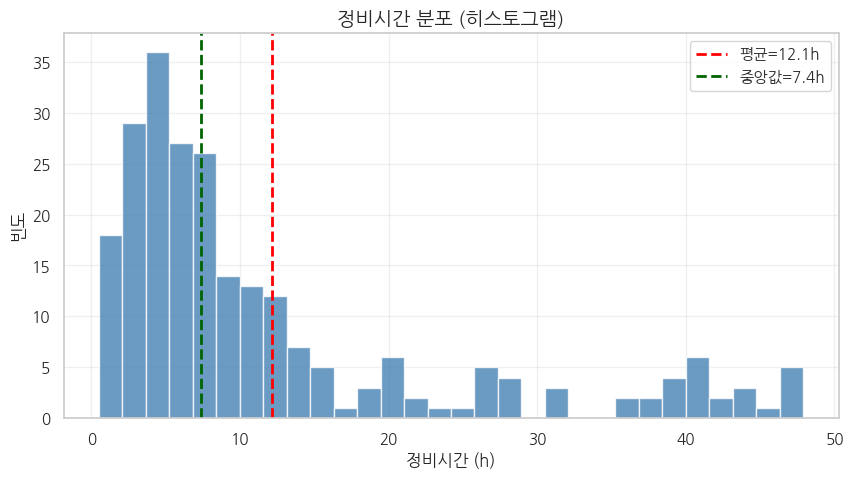

왜도(Skewness): 1.592
→ 오른쪽 꼬리 분포 (우측 치우침). 평균보다 중앙값이 더 대표적 ✅


In [61]:
plt.figure(figsize=(10, 5))
plt.hist(df['정비시간(h)'], bins=30,
         color='steelblue', edgecolor='white', alpha=0.8)

# 평균선과 중앙값선
mean_t   = df['정비시간(h)'].mean()
median_t = df['정비시간(h)'].median()
plt.axvline(mean_t,   color='red',      linestyle='--', linewidth=2, label=f'평균={mean_t:.1f}h')
plt.axvline(median_t, color='darkgreen',linestyle='--', linewidth=2, label=f'중앙값={median_t:.1f}h')

plt.title('정비시간 분포 (히스토그램)', fontsize=14, fontweight='bold')
plt.xlabel('정비시간 (h)'); plt.ylabel('빈도')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 분포 해석
skew = df['정비시간(h)'].skew()
print(f"왜도(Skewness): {skew:.3f}")
if skew > 1:
    print("→ 오른쪽 꼬리 분포 (우측 치우침). 평균보다 중앙값이 더 대표적 ✅")
elif skew < -1:
    print("→ 왼쪽 꼬리 분포 (좌측 치우침)")
else:
    print("→ 대체로 대칭 분포")

## 📊 왜도(Skewness) 1.592의 의미

**왜도(Skewness)는 "분포가 얼마나 한쪽으로 치우쳤는가"를 숫자로 나타낸 지표**예요. 0에 가까울수록 대칭이고, 절대값이 클수록 한쪽으로 꼬리가 길게 늘어진 모양입니다.

### 판정 기준

일반적으로 사용하는 경험 규칙은 이렇습니다:

| 왜도 값 | 분포 모양 | 해석 |
|---|---|---|
| `< -1` | 왼쪽 꼬리 길게 늘어짐 | 좌측 치우침(음의 왜도) |
| `-1 ~ -0.5` | 약간 좌측 치우침 | 살짝 비대칭 |
| `-0.5 ~ 0.5` | 거의 대칭 | 정규분포에 가까움 |
| `0.5 ~ 1` | 약간 우측 치우침 | 살짝 비대칭 |
| `> 1` | **오른쪽 꼬리 길게 늘어짐** | **강한 우측 치우침** |

지금 결과인 **1.592**는 마지막 구간에 해당해서 "강하게 오른쪽으로 꼬리가 늘어진 분포"라는 뜻입니다.

### 정비시간 데이터로 본 직관적 해석

히스토그램을 떠올리면:

```
빈도 │
     │ ▓▓▓
     │ ▓▓▓▓▓
     │ ▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▒▒▒▒▒▒▒░░░░  ← 오른쪽으로 길게 늘어진 꼬리
     └────────────────────────────────────→ 정비시간(h)
       (대부분 짧은 시간)              (가끔 매우 긴 정비)
```

대부분의 장비 정비는 **짧은 시간 안에 끝나는데**, 가끔 **엄청 오래 걸리는 정비 케이스(이상치)**가 일부 섞여 있어 오른쪽 꼬리를 길게 만든 것이에요. 부대 정비 데이터에서 매우 자연스러운 현상입니다 — 대부분은 일상적 점검·소수정비고, 일부는 중대고장이라 시간이 폭발적으로 늘어나죠.

### "평균보다 중앙값이 더 대표적" — 왜?

이게 이번 실습의 핵심 교훈입니다.

오른쪽 꼬리가 긴 분포에서는 소수의 큰 값(예: 정비시간 20시간짜리 중대고장 몇 건)이 **평균을 위로 끌어올립니다**. 반면 **중앙값은 순서상 한가운데 값**이라 이런 극단값에 흔들리지 않아요.

가상 예시로 보면:

- 정비시간 데이터: 1, 1, 2, 2, 2, 3, 3, 3, 4, **20** (시간)
- 평균 = 41 ÷ 10 = **4.1h** ← 단 한 건의 20h가 평균을 크게 끌어올림
- 중앙값 = (2+3)/2 = **2.5h** ← 실제 "보통" 정비시간에 훨씬 가까움

만약 지휘관에게 "우리 부대 평균 정비시간은 4.1시간입니다"라고 보고하면, 실제로는 대부분 2~3시간 안에 끝나는 현실을 왜곡하게 됩니다. 그래서 **우측 치우침 분포에서는 "중앙값"으로 보고하는 게 더 정직하고 실무적**이라는 거예요.

### 실무적 시사점 3가지

먼저, 이상치 관리가 중요합니다. 평균을 끌어올리는 그 긴 꼬리가 바로 "비정상적으로 오래 걸린 정비"이므로, 어떤 장비·어떤 고장유형에서 발생했는지 별도로 분석할 가치가 있습니다(Chapter 7의 인사이트 ③ 반복 고장 장비, 인사이트 ④ 가동불능 분석으로 이어지는 지점이에요).

다음으로, 보고서 작성 시 평균 대신 중앙값+사분위수(IQR)를 함께 쓰는 게 좋습니다. 박스플롯이 이런 분포에서 특히 효과적이고요(Chapter 4-3에서 배우는 바로 그 이유).

마지막으로, 수치형 변수가 한쪽으로 치우쳐 있으면 향후 머신러닝 단계에서 **로그 변환**(`np.log1p`) 같은 전처리를 고려하게 되는데, 이런 의사결정의 출발점이 바로 왜도 확인입니다.

요약하면 **"1.592 = 정비시간 데이터는 대부분 짧은 쪽에 몰려 있고, 가끔 매우 긴 정비 케이스가 평균을 위로 끌어올리는 비대칭 분포다. 따라서 부대에 보고할 때는 평균(mean)보다 중앙값(median)이 현실을 더 잘 대표한다"**는 의미입니다.

## 4-2. 월별 정비 건수 추이 — 선 그래프

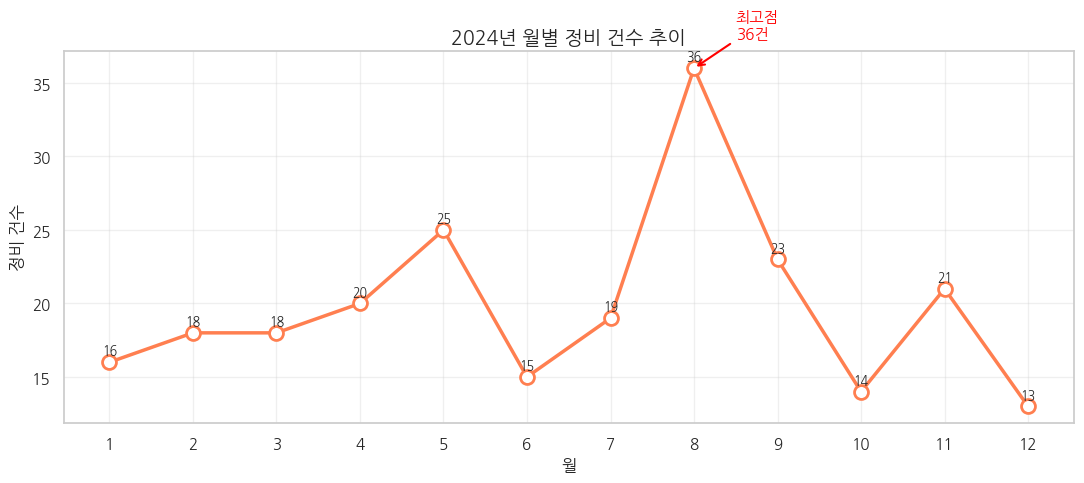

💡 최다 정비월: 8월 (36건)
   → 하계 훈련(6~8월) 후 누적 손모 원인으로 추정


In [62]:
monthly = df.groupby('월').size().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values,
         marker='o', color='coral', linewidth=2.5, markersize=10,
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='coral')

# 최대값 강조
peak_month = monthly.idxmax()
peak_value = monthly.max()
plt.annotate(f'최고점\n{peak_value}건',
             xy=(peak_month, peak_value),
             xytext=(peak_month + 0.5, peak_value + 2),
             fontsize=11, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# 각 지점에 값 표시
for m, v in monthly.items():
    plt.text(m, v + 0.5, str(v), ha='center', fontsize=9)

plt.title('2024년 월별 정비 건수 추이', fontsize=14, fontweight='bold')
plt.xlabel('월'); plt.ylabel('정비 건수')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💡 최다 정비월: {peak_month}월 ({peak_value}건)")
print(f"   → 하계 훈련(6~8월) 후 누적 손모 원인으로 추정")

## 4-3. 정비시간 박스플롯 — 이상치 시각화

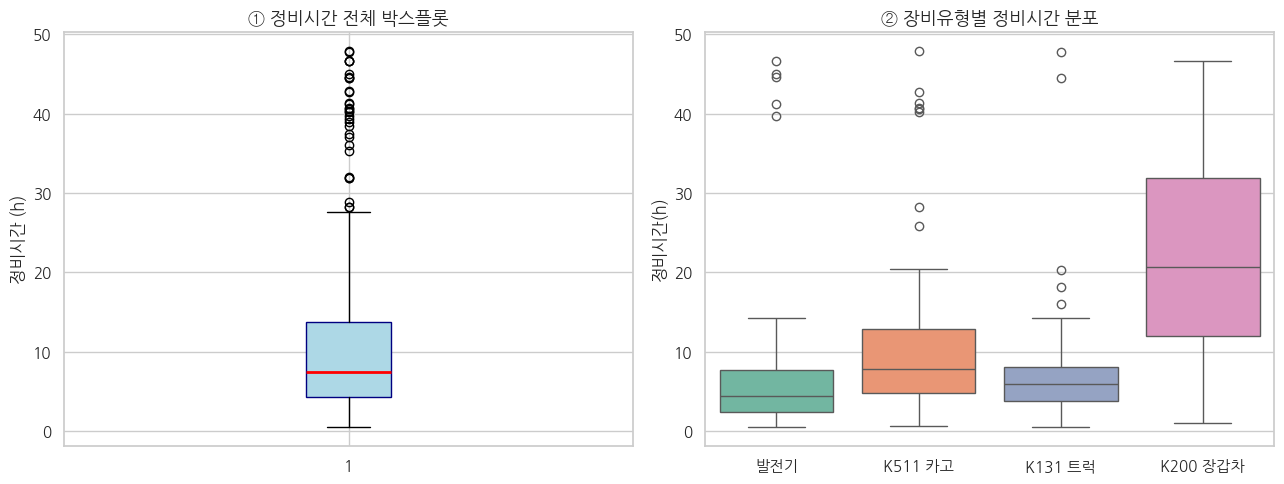

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 전체 박스플롯
axes[0].boxplot(df['정비시간(h)'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('① 정비시간 전체 박스플롯', fontsize=13, fontweight='bold')
axes[0].set_ylabel('정비시간 (h)')

# 장비유형별 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비시간(h)',
            palette='Set2', ax=axes[1])
axes[1].set_title('② 장비유형별 정비시간 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 📦 박스플롯 결과 해석 — 두 그림이 말하는 것

이 두 박스플롯은 정비시간 데이터의 **분포 구조**를 한눈에 보여주는 진단 도구예요. 그림 안에 어마어마하게 많은 정보가 압축돼 있는데, 하나씩 풀어서 읽어볼게요.

### 박스플롯 보는 법 다시 짚기

먼저 박스플롯의 각 부위가 뭘 의미하는지 정리하고 갈게요.

| 부위 | 의미 |
|---|---|
| **상자 아랫변** | Q1 (하위 25% 지점) |
| **상자 안의 가로선** | 중앙값 (Q2) |
| **상자 윗변** | Q3 (상위 25% 지점) |
| **상자의 높이** | IQR (가운데 50%의 폭) |
| **수염(whisker)** | 이상치가 아닌 정상 범위의 끝 |
| **수염 바깥의 동그라미** | 이상치 (1.5×IQR을 벗어난 점들) |

이걸 머릿속에 두고 두 그림을 읽어볼게요.

---

### ① 왼쪽 그림 — 정비시간 전체 박스플롯

**상자 자체의 위치와 모양**

상자가 대략 **4시간(Q1)에서 14시간(Q3) 사이**에 자리잡고 있고, 그 안의 **빨간 중앙값 선이 약 7~8시간 부근**에 그어져 있어요. 직전 셀에서 IQR 계산할 때 나왔던 `Q1=4.30h, Q3=13.75h`와 정확히 일치하는 모습입니다.

여기서 즉시 읽히는 두 가지 사실이 있어요. **첫째**, 상자 안에서 **중앙값 선이 정중앙이 아니라 아래쪽에 치우쳐** 있습니다. 빨간 선과 Q1 사이의 거리(약 3시간)가 빨간 선과 Q3 사이의 거리(약 6시간)보다 짧아요. 이는 **상자 내부에서도 분포가 비대칭**이라는 뜻이고, 부대 정비의 **중심부 50%조차도 우측으로 치우쳐 있다**는 신호입니다.

**둘째**, 수염의 길이도 비대칭이에요. 아래쪽 수염은 0 근처에서 끊기는데(정비시간이 음수일 수 없으니까), 위쪽 수염은 약 **28시간**까지 뻗어 있습니다. 정비시간 분포가 **위로 길게 끌려 있는 형태**라는 게 이 한 장의 그림으로 명확해져요.

**위쪽에 줄지어 선 동그라미들 — 핵심 메시지**

이 그림에서 가장 시선을 끄는 게 **30~50시간 구간에 몰려 있는 점들**입니다. 직전 셀에서 발견한 **31건의 이상치**가 바로 이 점들의 정체예요. 하나하나가 한 건의 정비 사례이고, 각각이 부대 자원에 큰 충격을 준 사건입니다.

특히 흥미로운 건 **이상치가 골고루 흩어진 게 아니라 30~48시간 구간에 빽빽하게 무리를 이룬다**는 점이에요. 만약 이상치가 단순한 입력 오류라면 무작위로 흩뿌려져야 하는데, 이렇게 군집을 이룬다는 건 **"긴 정비"라는 별도의 작업 카테고리가 실제로 존재**한다는 뜻입니다. 직전 분석에서 의심했던 "이중 모드 분포(짧은 일상 정비 + 긴 중정비)"가 시각적으로 확인되는 순간이에요.

---

### ② 오른쪽 그림 — 장비유형별 박스플롯

이 그림이 진짜 인사이트의 보고예요. 같은 정비시간 데이터인데 **장비유형으로 나눠서 다시 그렸을 뿐**인데도 보이는 그림이 완전히 달라집니다. 이게 EDA에서 **"한 차원 더 들어가서 보면 새로운 진실이 나타난다"**는 명제의 살아있는 예시예요.

#### 발전기 (왼쪽 첫 번째, 청록색)

상자가 가장 **납작하고 낮은 위치**에 있어요. 중앙값이 약 **4~5시간**, IQR도 매우 좁고(약 2~8시간), 수염도 14시간 부근에서 깔끔하게 끝납니다. **이상치가 거의 없는** 정직한 분포예요.

해석하면 — **발전기 정비는 표준화돼 있고 예측 가능합니다.** 정비병이 작업 일정을 짤 때 "발전기 1건 = 5시간"으로 잡으면 거의 빗나가지 않아요. 부품도 비교적 단순하고 고장 패턴도 정형화돼 있다는 의미죠. 부대 입장에서 가장 **관리하기 쉬운 장비군**입니다.

#### K511 카고 (왼쪽 두 번째, 주황색)

중앙값이 약 **8시간**으로 발전기보다 한 단계 위에 자리합니다. 상자 높이는 비교적 보통이고, 위쪽으로 **40시간대 이상치가 3~4건** 보여요. 수염도 약 20시간까지 뻗어 있고요.

해석 — **K511 카고는 평소엔 무난하지만 가끔 큰 사고를 친다.** 대부분의 정비는 5~13시간 안에 끝나는데, 한 번씩 변속기·엔진같은 중요 부품에 문제가 생기면 40시간을 넘기는 케이스가 발생해요. 직전 분석에서 본 K511의 "변속기 결함(42.7시간)", "엔진 이상(40.2시간)"이 바로 이 위쪽 점들이에요.

#### K131 트럭 (왼쪽 세 번째, 보라색)

K511과 비슷해 보이지만 자세히 보면 차이가 있어요. 상자는 K511보다 작고(약 4~9시간), 중앙값은 6시간 정도로 더 낮습니다. 다만 위쪽으로 **약 15~28시간 구간에 작은 이상치 무리**가 있어요. 40시간을 넘는 극단적 이상치는 거의 없습니다.

해석 — **K131은 K511보다 덜 위험하지만, 중간 강도의 이상치가 꾸준히 발생**합니다. 한방에 큰 사고를 치진 않지만, 예상보다 길어지는 정비가 종종 있다는 뜻이에요. 부품 수급 안정성이나 정비 매뉴얼의 명확성이 K511보다 좋은 편인 것 같습니다.

#### K200 장갑차 (오른쪽 끝, 분홍색) — 이 그림의 주인공

다른 세 박스플롯과 **완전히 다른 행성에서 온 그래프**처럼 보입니다.

상자 자체가 **약 12시간(Q1)부터 32시간(Q3)까지** 뻗어 있어요. 발전기·K131의 상자 전체보다 K200의 Q1이 더 높습니다. 즉, **K200 정비의 가장 짧은 25%조차도 다른 장비의 평균보다 훨씬 길다**는 의미예요.

중앙값은 약 **20~21시간**. 발전기 중앙값(4~5시간)의 **4배**에 달해요. 수염은 1시간 부근부터 47시간 부근까지, **거의 데이터의 전 범위를 한 장비가 차지**하는 모습입니다.

흥미로운 점은 K200에는 **"이상치"라고 표시된 동그라미가 거의 없다**는 거예요. 다른 장비에서는 30시간 넘는 정비가 명백한 이상치인데, K200에서는 30시간이 **정상 범위의 일상**입니다. 통계학이 보는 시각으로 — K200의 분포 자체가 다른 장비들과 본질적으로 다른 모집단이라는 거죠.

해석 — **K200 장갑차는 부대 정비 자원의 블랙홀입니다.** 한 번 정비대에 올라가면 평균 20시간, 길면 47시간이 걸리는, 다른 장비들과 차원이 다른 작업 부담을 안고 있어요. 직전 분석에서 봤던 "K200 궤도 마모 46.7시간"이 단발 사건이 아니라, 이 장비의 **구조적 특성**이라는 게 분명해집니다.

이게 합리적이긴 해요. K200은 무게 13톤급 장갑차로, 궤도·서스펜션·동력계가 일반 차량과 비교할 수 없을 만큼 복잡합니다. 한 부품을 떼어내려면 다른 부품 여러 개를 먼저 분해해야 하고, 부품 자체도 무겁고 비싸요. 정비시간이 길 수밖에 없는 **물리적·공학적 필연**이 있는 거죠.

---

### 두 그림을 같이 봤을 때 드러나는 진실

**왼쪽만 봤을 때는** "정비시간 분포가 우측 치우침이고 이상치가 많네" 정도의 결론이었어요. 그런데 **오른쪽까지 같이 보면** 전혀 다른 그림이 나옵니다.

왼쪽의 "이상치"는 **임의의 사고가 아니라 K200 장갑차라는 특정 장비군의 정상 분포**였어요. 즉, 정비시간 분포가 통계적으로 비대칭이었던 게 아니라, **다른 종류의 장비 분포 4개가 강제로 한 그래프에 합쳐져서 그렇게 보였던 것**이죠.

이걸 통계학에서는 **심슨의 역설(Simpson's Paradox)** 의 친척 격인 현상이라고 봐요. 합쳐진 데이터에서 보이는 패턴이 그룹별로 쪼개면 전혀 다르게 나타나는 현상. EDA에서 다변량 분석이 왜 필수인지를 보여주는 교과서적 사례입니다.

### 부대 운영에 시사하는 4가지 실무 결론

**첫째, 장비별로 정비 일정 표준이 달라야 합니다.** 발전기 1건당 5시간, K131 6~8시간, K511 8~10시간, K200 20~25시간을 기준선으로 삼아 인력·시간 자원을 배정해야 해요. 모든 정비를 똑같이 "1건"으로 세는 현행 방식은 K200을 만지는 정비반에 부당한 부담을 줍니다.

**둘째, K200 전담반의 필요성이 데이터로 입증됩니다.** 중앙값 20시간의 정비를 일반 정비반에 끼워넣으면 다른 작업이 모두 밀려요. K200을 전문적으로 다루는 별도 정비조직과 부품 비축을 갖추는 게 효율적입니다.

**셋째, K511의 "가끔 터지는 큰 사고"는 예방 가능성이 있습니다.** K511의 박스 자체는 양호한데 위쪽 이상치 몇 건이 평균을 끌어올리는 패턴이에요. 이 이상치들의 고장 유형(변속기·엔진 등)을 추적해 예방 점검 강화로 발생률을 낮추면, 부대 전체 정비 부담이 의미 있게 줄어듭니다.

**넷째, 발전기의 안정성을 다른 장비 정비 표준화의 모델로 삼을 만합니다.** 왜 발전기 정비는 이렇게 일관성 있을까? 매뉴얼? 부품 표준화? 정비병 숙련도? 그 노하우를 분석해 다른 장비에 이식하는 게 부대 정비 체계 개선의 또 다른 길이에요.

---

### 색상 선택에 대한 한 가지 메모

오른쪽 그래프는 `palette='Set2'`로 칠해져 있는데, 이 팔레트는 **각 카테고리에 시각적으로 구분되지만 어느 하나도 튀지 않는** 디자인이에요. 보고서용으로 적절한 선택입니다. 만약 K200을 강조하고 싶다면 K200만 빨간색으로 따로 칠하는 식의 변형도 가능해요.

다만 한 가지 살짝 아쉬운 점은, **왼쪽 그림(전체)과 오른쪽 그림(장비별)이 색상 코드가 연결되지 않는다**는 거예요. 왼쪽의 lightblue 박스와 오른쪽의 4가지 색이 무관해서, 두 그림이 같은 데이터를 다른 각도로 본 것이라는 시각적 단서가 약합니다. 이건 본 셀의 한계라기보다는, 시각화 고도화의 다음 단계 아이디어로 두면 좋을 부분이에요.

---

### 다음 분석으로 자연스럽게 이어지는 질문들

이 그림을 본 사람이라면 자연스럽게 다음 질문이 떠오를 거예요:

"K200 장갑차의 정비시간이 길면 비용도 그만큼 더 들까?" → **Chapter 5-1 장비유형별 평균 정비비용**에서 확인.

"정비시간과 비용의 관계는 얼마나 강할까?" → **Chapter 5-2 상관관계 + 산점도**에서 정량화.

"K200 안에서도 어떤 고장 유형이 가장 길게 만들까?" → **Chapter 5-3 피벗 테이블**로 분해.

"K200을 시간대별로 나눠보면 8월에 또 몰릴까?" → **Chapter 5-3 월×장비유형 히트맵**에서 검증.

박스플롯이 발견한 "K200이 다르다"는 사실이, 이후 모든 다변량 분석의 출발점이 되는 거죠.

요약하면 이 두 그림은 **"정비시간 데이터의 비대칭성과 이상치는 사실 K200 장갑차라는 특정 장비군의 구조적 특성에서 비롯된 것이며, 부대 정비 자원의 가장 큰 단일 변수는 K200의 존재 자체"**라는 결론을 한 화면으로 보여주고 있어요. 단변량 분석에서 다변량 분석으로 넘어가는 결정적 다리이자, 부대 정비 체계 개선 논의의 출발점이 되는 그림입니다.

---
### 🔥 실습문제 4 - 단변량 분석
1. **정비비용** 분포의 **히스토그램** (bins=30) + 평균·중앙값선
2. **분기별(Q1~Q4)** 정비 건수 막대그래프
3. **장비유형별 정비비용** 박스플롯
4. **요일별** 정비 건수를 막대그래프로 시각화 (월~일 순)

In [38]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

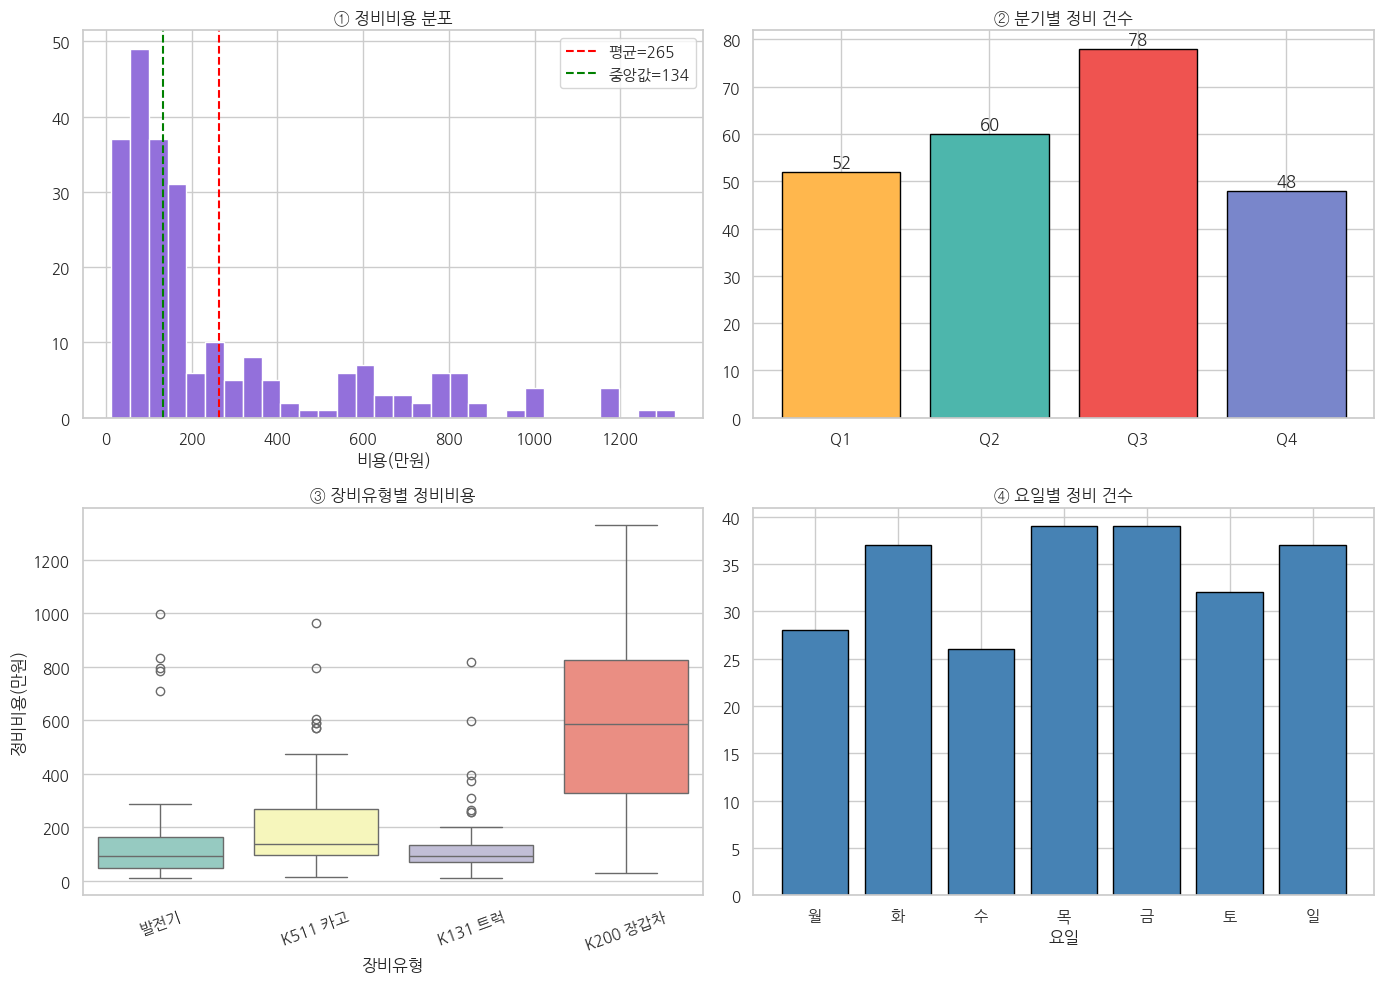

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) 정비비용 히스토그램
axes[0,0].hist(df['정비비용(만원)'], bins=30,
               color='mediumpurple', edgecolor='white')
m = df['정비비용(만원)'].mean()
md_v = df['정비비용(만원)'].median()
axes[0,0].axvline(m, color='red', linestyle='--', label=f'평균={m:.0f}')
axes[0,0].axvline(md_v, color='green', linestyle='--', label=f'중앙값={md_v:.0f}')
axes[0,0].set_title('① 정비비용 분포', fontweight='bold')
axes[0,0].set_xlabel('비용(만원)'); axes[0,0].legend()

# 2) 분기별 정비 건수
q_cnt = df.groupby('분기').size()
bars = axes[0,1].bar(q_cnt.index, q_cnt.values,
                     color=['#FFB74D','#4DB6AC','#EF5350','#7986CB'], edgecolor='black')
for bar, v in zip(bars, q_cnt.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   str(v), ha='center', fontweight='bold')
axes[0,1].set_title('② 분기별 정비 건수', fontweight='bold')
axes[0,1].set_xticks([1,2,3,4])
axes[0,1].set_xticklabels(['Q1','Q2','Q3','Q4'])

# 3) 장비유형별 비용 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비비용(만원)',
            palette='Set3', ax=axes[1,0])
axes[1,0].set_title('③ 장비유형별 정비비용', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# 4) 요일별 정비 건수
weekday_order = ['월','화','수','목','금','토','일']
wd_cnt = df['요일_한글'].value_counts().reindex(weekday_order, fill_value=0)
axes[1,1].bar(wd_cnt.index, wd_cnt.values, color='steelblue', edgecolor='black')
axes[1,1].set_title('④ 요일별 정비 건수', fontweight='bold')
axes[1,1].set_xlabel('요일')

plt.tight_layout()
plt.show()

## 📊 4종 차트 종합 분석 — 부대 정비의 4가지 얼굴

이 셀은 단변량 분석의 종합 정리에 해당하는 **4-in-1 시각화**예요. `subplots(2, 2)`로 한 화면에 4개 차트를 동시에 띄워 정비 데이터의 다른 차원들을 한 번에 비교할 수 있게 해주는 구성이고, 각 차트가 던지는 메시지가 모두 다르면서도 서로 보완 관계예요. 하나씩 깊게 읽어볼게요.

---

### ① 정비비용 분포 (좌상단 히스토그램) — 비용의 진실

**가장 충격적인 그림입니다.** 평균=265만원과 중앙값=134만원, 두 선이 거의 두 배 차이로 떨어져 있어요. 이게 무엇을 의미하는지 곱씹어볼 가치가 있습니다.

분포를 보면 **0~200만원 구간**에 막대들이 빽빽하게 몰려 있어요. 가장 높은 막대는 50~100만원 구간으로 약 49건이고, 그 다음이 100~150만원 구간 약 37건, 0~50만원 구간 약 37건이에요. 즉 **전체 정비의 절반 이상이 200만원 미만**에서 끝납니다.

그런데 오른쪽으로 눈을 돌리면 **600만원, 800만원, 1000만원, 1200만원**까지 점점이 막대들이 흩어져 있어요. 한 건이지만 1300만원짜리 정비도 있고요. 이 소수의 고비용 정비들이 평균을 134만원에서 265만원으로 끌어올린 주범입니다.

**평균과 중앙값의 격차가 1.98배**라는 게 핵심이에요. 정비시간 분포의 왜도가 1.59였는데, 비용 분포는 시각적으로 **그보다 더 강한 우측 치우침**을 보여줍니다. 비용의 왜도를 계산하면 아마 2.5~3 사이가 나올 거예요.

이 그림이 부대 보고에 시사하는 바는 명확합니다. **"우리 부대 평균 정비비용은 265만원입니다"라고 보고하면 거짓말에 가까워요.** 정비 100건 중 절반이 134만원 미만에서 끝나는데, 평균은 265만원이라고 말하면 듣는 사람은 "보통 정비가 265만원쯤 든다"고 받아들이거든요. **"중앙값 134만원, 다만 일부 고비용 정비가 평균을 265만원까지 끌어올림"**이라고 함께 말해야 정직한 보고가 됩니다.

또 하나, 1000만원을 넘는 정비가 **이산적으로 4~5건 띄엄띄엄** 있다는 점도 의미 있어요. 이게 단순한 이상치가 아니라 **"부대 정비에는 백만원대 일상 정비와 천만원대 중정비라는 두 종류가 존재한다"**는 신호일 수 있습니다. 박스플롯에서 봤던 K200의 분포가 여기서도 비용 차원으로 다시 모습을 드러내는 거예요.

---

### ② 분기별 정비 건수 (우상단 막대그래프) — 계절성의 정량화

이전 셀에서 본 월별 추이를 분기 단위로 묶은 그림입니다. **Q3(7~9월)이 78건으로 압도적**이고, Q2 60건, Q1 52건, Q4 48건이에요.

**Q3가 다른 분기들보다 30~60% 많다는 게 핵심**입니다. 1년을 단순히 4등분해서 본다면 분기당 60건이 평균인데, Q3만 거의 80건이고 나머지는 50건 안팎이죠. 즉 **부대 연간 정비 작업의 약 1/3이 Q3 단 3개월에 몰립니다**(78 ÷ 238 ≈ 33%).

이 분기별 패턴은 월별 그래프(8월 피크)가 분기 차원으로 확대 재생산된 거예요. 그런데 분기로 봤을 때 추가로 드러나는 정보가 있습니다.

**Q1 → Q2 → Q3로 점진적 증가, Q3 → Q4로 급감**이라는 흐름이에요. 부대 운용 사이클을 떠올려보면 자연스럽습니다. Q1은 동계 훈련의 끝물이라 누적 손모가 일부 발생, Q2는 봄 정비 시즌이 본격화되며 점차 증가, Q3에는 하계 훈련 직후 누적 손모가 폭발, Q4에는 동계 진입 전 점검 모드로 줄어드는 흐름이죠.

다만 한 가지 주의할 점은, **이 패턴이 단일 연도(2024년) 데이터에서 나온 것**이라는 거예요. 다년간 데이터로 검증하기 전에는 "이 부대의 영구적 패턴"이라기보다 "2024년에 관찰된 패턴"이라고 표현하는 게 정직합니다. 만약 2025·2026년에도 같은 Q3 피크가 반복된다면 그때 비로소 **"이 부대의 구조적 계절성"**이라고 결론 내릴 수 있어요.

색상 선택도 짚어볼 만합니다. Q3에 빨간색(#EF5350)을 쓴 게 의도적이에요. **"가장 부담이 큰 분기"라는 메시지를 색으로 강조**하는 방식이죠. 막대 위 숫자도 굵게 표시(`fontweight='bold'`)해서 정확한 값을 한눈에 볼 수 있게 했고요.

---

### ③ 장비유형별 정비비용 박스플롯 (좌하단) — 비용의 K200 효과

이 그림은 직전 셀의 **정비시간 박스플롯과 거의 똑같은 패턴**을 비용 차원에서 다시 한번 보여줍니다. 같은 결론이 시간과 비용 두 차원에서 모두 확인된다는 건, K200의 특수성이 우연이 아니라 **구조적 사실**임을 강력히 입증해요.

**발전기**: 중앙값 약 100만원, 상자가 50~200만원 사이에 자리. 이상치가 4~5건 위쪽으로 보이는데(700~1000만원 구간), 이건 발전기 정비 중에서 예외적으로 비싼 케이스들이에요. 평소엔 저렴하지만 가끔 큰 부품을 갈아야 할 때가 있다는 신호.

**K511 카고**: 중앙값 약 130만원, 상자가 100~280만원 정도로 발전기보다 한 단계 위. 이상치가 600~970만원 구간에 5~6건 분포해요. 정비시간 박스플롯에서 봤던 "가끔 터지는 큰 사고" 패턴이 비용에서도 동일하게 재현됩니다.

**K131 트럭**: 가장 흥미로운 박스예요. 상자 자체는 작고(약 70~150만원) 중앙값도 100만원 부근으로 낮은데, **이상치가 200~600만원 구간에 7~8건**이나 흩어져 있어요. 이게 무슨 뜻이냐면 — **K131의 "보통" 정비는 매우 저렴한데, 한 번 비싸지면 보통의 5~6배까지 튄다**는 거예요. 비용 변동성이 가장 큰 장비입니다. 부품 가격이 양극화돼 있거나(소모품은 싸고 핵심 부품은 비싸고), 고장 유형의 분포가 이중 모드일 가능성이 있어요.

**K200 장갑차**: 다시 한번 다른 차원의 분포입니다. 상자 자체가 **약 320만원~830만원**, 중앙값이 약 590만원이에요. 발전기 중앙값(100만원)의 **거의 6배**, K511의 4.5배입니다. 게다가 위쪽 수염은 1300만원 부근까지 뻗고, 아래쪽 수염도 약 50만원까지 내려가요. **변동 폭만 1250만원**입니다. 이상치 표시가 거의 없는 것도 직전 시간 박스플롯과 같은 이유예요 — K200에서는 600~1300만원이 정상 범위입니다.

**시간 박스플롯과 비용 박스플롯을 겹쳐 보면** 매우 강력한 결론이 나옵니다: **K200은 정비시간도 길고 정비비용도 비싸다.** 이 두 변수가 강한 양의 상관을 보일 거라는 예측이 자연스럽게 나오고, 이게 다음 챕터(Chapter 5-2 상관관계 분석)로 연결되는 자연스러운 다리예요.

---

### ④ 요일별 정비 건수 (우하단 막대그래프) — 의외의 평탄함

이 그림이 가장 **반전 있는** 결과예요. 보통 군부대 정비라고 하면 평일에 몰리고 주말은 적을 것 같은데, 데이터는 다른 그림을 보여줍니다.

목·금이 39건씩으로 가장 많고, 화요일과 일요일이 37건, 토요일 32건, 월요일 28건, 수요일 26건이에요. **요일별 편차가 26~39건 사이로 의외로 균등**합니다. 가장 많은 목·금과 가장 적은 수요일의 차이가 1.5배 정도인데, 분기별 격차(Q3 78 vs Q4 48, 1.6배)와 비슷한 수준이지만 의미는 완전히 달라요.

**관찰 1 — 주말이 줄지 않는다.** 토요일 32건, 일요일 37건은 평일 평균과 거의 같은 수준이에요. 이는 부대 정비가 **5일제 근무가 아닌 상시 운영 체제**임을 시사합니다. 군 특성상 당연한 결과지만, 데이터로 확인되니 인상적이죠. 일요일이 토요일보다 오히려 많은 건 토요일에 발견된 고장이 일요일에 처리되는 패턴일 수도 있어요.

**관찰 2 — 월요일·수요일이 가장 적다.** 월요일이 적은 건 흔히 보이는 패턴(주말에 누적된 일이 화·목으로 분배)이라 이해되지만, **수요일이 가장 적은 건 흥미롭습니다**. 부대 운영상 수요일에 정기 훈련이나 회의가 있어 정비 작업을 의도적으로 피하는 일정 관행이 있을 수 있어요. 또는 화요일에 집중적으로 처리하고 목요일에 다시 시작하는 작업 흐름이거나요.

**관찰 3 — 목·금에 살짝 몰린다.** 주말 직전 처리 압박이 있을 수 있습니다. "이번 주 안에 끝내자"는 운영적 동기, 또는 주말 작전 대비 사전 점검 강화의 결과로 해석 가능해요.

다만 이 모든 해석은 어디까지나 **가설**입니다. 요일별 차이가 통계적으로 유의미한지 검증하려면 카이제곱 검정 같은 통계 검증이 필요해요. 시각적으로는 차이가 있어 보여도 표본 크기에 비해 우연 변동의 범위 안일 수 있거든요.

**부대 운영 시사점**으로 정리하면 — 정비 작업 일정이 요일에 크게 의존하지 않으므로 **요일별 인력 배치는 균등하게**, 다만 약간의 차등(수요일 ↓, 목·금 ↑)을 두는 게 효율적일 수 있습니다.

---

### 4개 차트가 함께 던지는 메시지

각 차트를 따로 보면 단편적 사실이지만, 4개를 동시에 보면 **부대 정비의 종합 프로필**이 그려집니다.

먼저 **"비용 측면의 위험 분포"**가 보여요. ①번에서 평균과 중앙값의 큰 격차로 비용 분포가 강하게 우측 치우침을 확인했고, ③번에서 그 우측 꼬리의 정체가 K200 장갑차임을 분해해서 봤습니다. 즉 **부대 정비 비용 위험은 K200에 집중**돼 있다는 결론.

다음으로 **"시간적 부담의 분포"**예요. ②번 분기별 차트는 Q3에 부담이 몰린다는 시간적 집중을 보여주고, ④번 요일별 차트는 그 부담이 한 주 안에서는 골고루 분산된다는 미시적 균형을 보여줍니다. **장기(분기) 차원에서는 집중적이지만 단기(주) 차원에서는 분산적**인 이중 구조죠.

종합하면 부대 정비 운영의 **두 가지 핵심 변수**는 (1) **장비 유형(특히 K200의 비중)** 과 (2) **계절(특히 Q3의 집중)** 입니다. 인력·예산·부품 비축 계획은 이 두 축을 따라 설계돼야 한다는 게 데이터가 가리키는 방향이에요.

---

### 시각화 코드의 디자인 노트 한 가지

이 4-in-1 차트의 구성에 대해 **차트 종류 선택**이 흥미로워요:

| 위치 | 변수 | 차트 종류 | 선택 이유 |
|---|---|---|---|
| ① | 정비비용(수치형) | 히스토그램 | 분포의 모양·치우침 확인 |
| ② | 분기(범주형) | 막대그래프 | 카테고리별 양 비교 |
| ③ | 장비×비용 | 박스플롯 | 그룹별 분포 비교 |
| ④ | 요일(범주형) | 막대그래프 | 카테고리별 양 비교 |

**데이터 타입에 따라 차트가 결정**되는 원칙이 그대로 적용된 거예요. Chapter 6의 "차트 선택 가이드"가 사실 이 코드에 이미 자연스럽게 녹아 있는 셈입니다. 좋은 EDA는 차트 종류를 의식하지 않고도 데이터 타입을 보면 적절한 차트가 자동으로 떠오르는 단계가 목표예요.

---

### 한 가지 발전 아이디어 — 비용을 로그 스케일로

①번 히스토그램에서 우측의 1000만원대 데이터들이 너무 띄엄띄엄해서 그 영역의 패턴이 잘 안 보여요. 이런 강한 우측 치우침 분포에서는 **로그 스케일 히스토그램**이 더 정보 가치가 높습니다:

```python
axes[0,0].hist(np.log10(df['정비비용(만원)']), bins=30)
```

이렇게 하면 1만원~1300만원이 0~3 범위로 압축되면서 분포의 세부 모양이 훨씬 잘 보여요. 다만 보고서용으로는 일반인이 직관적으로 읽기 어려우니, **분석용 차트와 보고용 차트를 따로 만드는 것**이 실무 패턴입니다. 분석은 로그 스케일로 깊이 들여다보고, 보고는 원래 스케일로 단순하게.

요약하면 이 한 화면이 **"부대 정비의 비용·시간·시기·요일이라는 4개 차원에서의 부담 구조를 동시에 진단"**해주고 있어요. 각 차트는 독립적인 정보를 주지만, 4개를 함께 봤을 때 비로소 **"K200×Q3"이라는 부대 정비 위험의 핵심 좌표**가 도출됩니다. 단변량 분석이 끝나는 지점에서 다변량 분석이 왜 필요한지를 자연스럽게 보여주는 마무리예요.

---
# 🔗 Chapter 5. [Step 5] 다변량 분석 (Multivariate Analysis)

> **두 개 이상** 의 변수 간 **관계** 를 분석하는 단계  
> → groupby, 상관분석, heatmap이 주력 도구

## 5-1. 장비유형별 평균 정비비용 — 수평 막대그래프

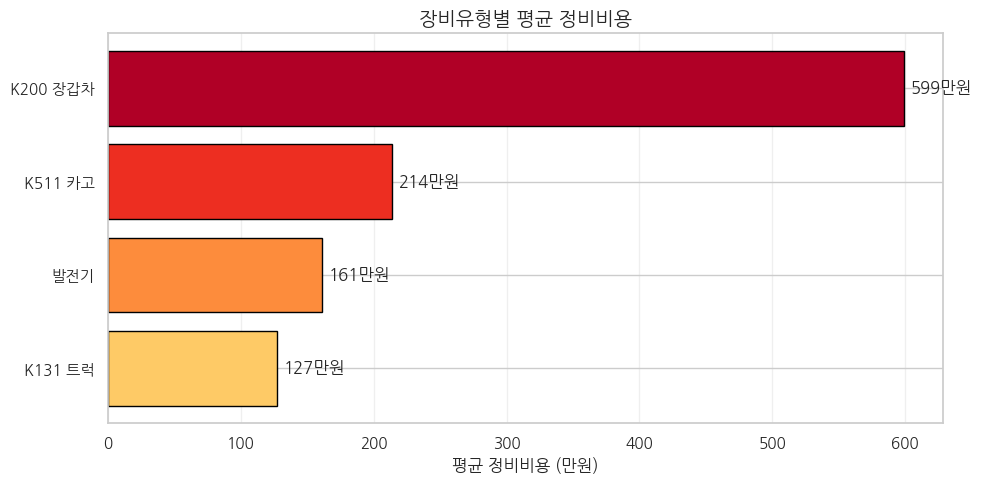

💡 K200 장갑차 비용이 K131 트럭의 4.7배


In [65]:
equip_cost = df.groupby('장비유형')['정비비용(만원)'].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(equip_cost)))
bars = plt.barh(equip_cost.index, equip_cost.values,
                color=colors, edgecolor='black')

# 막대 끝에 값 표시
for bar, v in zip(bars, equip_cost.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{v:.0f}만원', va='center', fontweight='bold')

plt.title('장비유형별 평균 정비비용', fontsize=14, fontweight='bold')
plt.xlabel('평균 정비비용 (만원)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 해석
max_equip = equip_cost.idxmax()
min_equip = equip_cost.idxmin()
ratio = equip_cost.max() / equip_cost.min()
print(f"💡 {max_equip} 비용이 {min_equip}의 {ratio:.1f}배")

## 💰 장비유형별 평균 정비비용 — 한 줄로 요약되는 결정적 진실

이 셀은 EDA의 다변량 분석 첫 번째 그림이에요. 직전까지의 박스플롯들이 **분포의 모양 전체**를 보여줬다면, 이 그림은 **각 그룹의 대표값(평균)만 추려서** 깔끔한 비교를 만들어내는 단계입니다. 정보 밀도는 낮아지지만 메시지 전달력은 극대화되는, 보고서 표지에 자주 등장하는 형식의 차트예요.

---

### 데이터 한 줄이 만든 결정적 그림

**`equip_cost = df.groupby('장비유형')['정비비용(만원)'].mean().sort_values()`**

이 한 줄이 그림의 모든 것을 만들어냅니다. 풀어보면:

먼저 `groupby('장비유형')`으로 4개 장비군을 나누고, `['정비비용(만원)']`으로 그중 비용 컬럼만 선택해, `.mean()`으로 그룹별 평균을 계산한 뒤, `.sort_values()`로 작은 값부터 큰 값 순으로 정렬했어요. 정렬 순서가 중요한데 — 수평 막대그래프(`barh`)는 위에서 아래로 그려지므로 오름차순 정렬을 하면 **위로 갈수록 큰 값**이 오는 자연스러운 시각이 됩니다(반대로 정렬하면 거꾸로 그려짐).

이 한 줄에 담긴 패턴 — **`groupby → 컬럼선택 → 집계함수 → 정렬`** — 은 Pandas로 데이터를 분석할 때 가장 자주 쓰는 4단 콤보예요. 이 한 패턴만 익숙해지면 EDA의 90%는 그릴 수 있습니다.

---

### 색상 그라데이션의 영리한 선택

**`colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(equip_cost)))`**

색상 선택이 의도적이에요. `YlOrRd`는 노랑→주황→빨강으로 이어지는 컬러맵으로, 대표적인 **순차형(sequential) 팔레트**입니다. 이 팔레트는 "값이 클수록 색이 강해진다"는 직관적 매핑을 자연스럽게 만들어줘요.

`np.linspace(0.3, 0.9, 4)`로 4개 색상을 균등하게 뽑되, 0~1 양 끝(너무 옅거나 너무 짙음)을 피해 0.3~0.9 구간만 사용했어요. 이건 시각화의 **고급 디테일**입니다. 너무 옅은 노랑은 가독성이 떨어지고 너무 짙은 빨강은 답답해 보이거든요.

결과적으로 K131(가장 저렴) = 옅은 노랑, K200(가장 비쌈) = 진한 빨강이 자동으로 매핑됐습니다. **위험도가 높은 항목이 빨갛게 보이는** 시각적 직관과 정확히 일치하는 컬러 코딩이에요.

---

### 결과 숫자가 보여주는 충격적 격차

| 장비유형 | 평균 비용 | 가장 저렴한 장비 대비 |
|---|---|---|
| K131 트럭 | 127만원 | 1.0배 (기준) |
| 발전기 | 161만원 | 1.27배 |
| K511 카고 | 214만원 | 1.69배 |
| **K200 장갑차** | **599만원** | **4.7배** |

이 표가 던지는 메시지는 명확하면서도 충격적이에요. **K200 장갑차의 평균 정비비용은 K131 트럭의 4.7배**입니다. 다른 모든 장비는 100~250만원 사이의 좁은 구간에 모여 있는데, K200만 600만원에 가까운 값으로 **혼자만 다른 차원**에 있어요.

직전 박스플롯 분석에서 봤던 패턴이 **하나의 숫자로 압축**되는 순간입니다. 박스플롯은 분포의 풍부함을 다 보여주지만, 의사결정자에게 "그래서 결론이 뭐냐?"고 한 번에 답하기 어려워요. 이 막대그래프는 그 질문에 한 줄로 답합니다 — **"K200이 다른 장비의 5배 비용"**.

---

### 4.7배가 의미하는 부대 운영의 실제

이 비율을 부대 살림에 환산해보면 더 와닿습니다.

**가상 시나리오 ①** — K131 트럭 정비 1건 = 발전기 정비 1.27건. 비슷한 부담입니다. 만약 K131 정비 100건의 예산이 1.27억원이라면, 같은 예산으로 발전기는 약 79건을 정비할 수 있어요. **실용적 등가 관계**가 성립합니다.

**가상 시나리오 ②** — K200 정비 1건 = K131 정비 4.7건. 즉 K200을 한 번 정비대에 올리는 비용으로 **K131 트럭 4~5대를 정비**할 수 있어요. 부대 입장에서 K200 한 대의 정비를 미루면 K131 4~5대 분량의 예산 부담이 사라지는 구조죠.

**가상 시나리오 ③** — 만약 부대에 K200이 5대, K131이 5대 있다면? 같은 횟수 정비를 받는다고 가정해도 K200 정비비가 K131의 4.7배니까, **K200 5대가 부대 정비예산의 약 80%**를 흡수합니다. 장비 보유 대수가 같아도 예산 배분은 극도로 비대칭이라는 의미예요.

이게 단순한 "K200이 비싸다"의 문제가 아니라 **부대 예산 구조 자체가 K200 한 종에 의해 결정되는 종속 관계**라는 사실을 드러냅니다.

---

### 평균값이라는 한계, 그리고 박스플롯이 필요한 이유

이 차트의 가장 큰 약점은 **평균만 보여준다**는 것이에요. 평균은 강력한 요약 통계지만, 정보 손실이 큽니다.

K200의 평균 599만원이 의미하는 게 정확히 무엇일까요? "모든 K200 정비가 600만원쯤 한다"는 뜻이 아니에요. 직전 셀의 박스플롯에서 본 K200의 분포를 떠올리면 — 중앙값 590만원, 상자(Q1~Q3)가 320~830만원, 수염은 약 50만원에서 1300만원까지. 즉 **"K200 정비 비용은 50만원에서 1300만원까지 매우 넓게 흩어져 있고, 그 평균이 우연히 599만원"**인 거예요.

이 점이 시사하는 건 **막대그래프와 박스플롯이 짝을 이뤄 보고돼야 한다**는 거예요. 막대그래프는 의사결정자에게 "어디에 집중해야 하는가"를 한 줄로 알려주고, 박스플롯은 분석가에게 "그 그룹 안에서도 변동이 얼마나 큰가"를 보여줍니다. 둘 다 필요해요.

만약 K200의 평균이 599만원이지만 박스플롯에서 봤듯 분포가 320~830만원으로 매우 넓다면, **"K200 평균 599만원"이라는 보고는 사실이지만 절반의 진실**이에요. "K200 정비비는 보통 320~830만원, 평균 599만원"이라고 분포 정보를 함께 전달하는 게 더 정직한 보고입니다.

---

### 평균과 중앙값을 함께 보면

직전 4-in-1 차트에서 본 정비비용 분포(전체)는 평균 265만원, 중앙값 134만원으로 거의 두 배 격차가 있었어요. 그런데 이 막대그래프의 **장비유형별 평균**을 가중평균하면 그 265만원이 정확히 재현됩니다.

만약 같은 분석을 평균이 아닌 **중앙값**으로 다시 그려보면 다른 그림이 나올 거예요:

```python
equip_cost_med = df.groupby('장비유형')['정비비용(만원)'].median().sort_values()
```

K200의 중앙값은 약 590만원으로 평균(599)과 거의 같지만, **K511 카고는 평균 214 vs 중앙값 약 130만원** 정도로 큰 차이가 날 가능성이 높습니다(박스플롯에서 K511이 위쪽으로 이상치를 많이 끌고 있던 것 기억하시죠). 이 차이가 의미하는 건 — **K511의 평균은 소수의 비싼 정비에 끌려간 값**이고, "보통의 K511 정비"는 130만원 수준이라는 거예요.

평균 차트만 보면 K511 ≈ 발전기로 비슷해 보이지만, 중앙값 차트로 보면 K511이 발전기보다 더 저렴할 수도 있어요. **어떤 통계량을 쓰느냐에 따라 순위마저 바뀌는 것**, 이게 EDA에서 통계적 사고가 중요한 이유입니다.

---

### 막대그래프 디테일 — 끝에 값 표시하기

**`plt.text(bar.get_width() + 5, ...)`**

각 막대 끝에 정확한 숫자를 표시한 게 보고서 품질의 핵심이에요. 이 한 단계 차이가 그래프를 "예쁜 그림"에서 "정보 전달 도구"로 격상시킵니다.

`bar.get_width()`로 막대의 끝 X좌표를 가져온 뒤 `+5`로 살짝 떨어뜨려 텍스트를 배치했어요. 이 5라는 오프셋은 데이터 스케일에 비례해 조정해야 하는 값이에요. 비용이 만원 단위라 5만원이 적절한 간격이지만, 만약 단위가 원이었다면 5원으론 텍스트가 막대에 겹쳐 보일 거고 5000원쯤은 돼야 했겠죠.

`va='center'`(vertical alignment)로 텍스트가 막대 정중앙 높이에 오게 했고, `fontweight='bold'`로 굵게 표시해서 막대 끝에서 시선이 자연스럽게 숫자로 옮겨가게 만들었습니다.

---

### 마지막 출력문이 만드는 마무리

**`print(f"💡 {max_equip} 비용이 {min_equip}의 {ratio:.1f}배")`**

이 한 줄이 그래프의 결론을 자동으로 텍스트화합니다. 시각화는 "보여주기"이고 텍스트는 "정리하기"인데, 둘이 함께 있어야 보고서가 완성돼요.

`equip_cost.idxmax()`와 `idxmin()`은 가장 큰 값과 작은 값을 가진 **인덱스(=장비명)**를 반환하고, `.max() / .min()`은 그 값들의 비율을 계산합니다. 데이터가 바뀌어도 이 코드는 자동으로 적응하므로, **재사용 가능한 분석 템플릿**이 되는 패턴이에요.

`💡` 이모지는 "이게 핵심 인사이트"라는 시각적 표시. 노트북을 스크롤하다 보면 이 이모지 줄에서 시선이 멈추게 됩니다.

---

### 이 그림이 다음 분석으로 던지는 질문들

이 막대그래프 한 장이 자연스럽게 다음 챕터로 넘어가는 다리를 놓습니다.

**"K200이 비싼 이유는 정비시간이 길기 때문일까?"** — 이전 박스플롯에서 K200의 정비시간이 다른 장비의 4배였고, 정비비용도 4.7배예요. 두 변수가 거의 같은 비율로 움직인다는 게 우연일 리 없죠. 다음 셀(Chapter 5-2)의 **상관관계 분석**이 이 직감을 정량화해줄 겁니다. 만약 시간-비용 상관계수가 0.8 이상으로 나온다면 "정비비용은 거의 정비시간으로 결정된다"는 강한 결론이 도출돼요.

**"K200의 비용은 어떤 고장유형에서 가장 비쌀까?"** — 평균 599만원도 그 안에서 다양해요. 궤도 마모, 엔진 이상, 변속기 결함 같은 고장유형별로 비용이 어떻게 다른지 분해해보면 "어떤 부품 비축에 우선순위를 둘지"가 명확해집니다. **Chapter 5-3 피벗 테이블**에서 다뤄질 내용이에요.

**"이 비용 격차에 부대 차이가 있을까?"** — 같은 K200이라도 A부대와 B부대가 다를 수 있어요. 정비병 숙련도, 부품 조달 경로, 작업 환경이 영향을 줄 수 있습니다. **Chapter 9 미니 프로젝트**의 "담당부대 관점 EDA"가 바로 이 질문에 답하는 단계예요.

---

### 한 가지 발전 아이디어 — 정비 건수 대비 비용

이 그래프는 "건당 평균 비용"만 보여주지만, 부대 예산 입장에서는 **"총 비용 부담"**이 더 중요할 수 있어요. K200이 건당 599만원이어도 정비 건수가 적으면 부대 전체 예산에서 차지하는 비중은 낮을 수도 있거든요.

```python
total_cost = df.groupby('장비유형')['정비비용(만원)'].sum().sort_values()
```

이렇게 합계로 그려보면 "건당 평균"과는 다른 순위가 나올 가능성이 있어요. 예를 들어 K511 카고가 정비 건수가 많아 평균은 낮아도 총합으로는 K200을 따라잡을 수 있죠. **"건당 부담" vs "총 부담"** 두 관점은 다른 의사결정에 쓰입니다 — 건당 부담은 정비 효율 개선, 총 부담은 예산 배분에 각각 직결돼요. Chapter 7-1의 인사이트가 정확히 이 두 차원을 함께 분석하는 단계입니다.

---

### 요약하면

이 그림은 **부대 정비 분석의 결정적 한 줄을 만들어내는 차트**예요. "K200 장갑차의 평균 정비비용은 다른 장비들보다 4.7배 높다"라는 단순하지만 무거운 결론을, 평균 → 정렬 → 색상 그라데이션 → 값 표시라는 4단계 시각화 기법으로 즉시 전달합니다.

박스플롯이 분포 전체의 풍부한 정보를 보여줬다면, 이 막대그래프는 **그 풍부함을 의사결정에 쓸 수 있는 "한 숫자"로 압축**해요. EDA의 흐름에서 보면 박스플롯이 **분석가의 도구**, 막대그래프가 **보고자의 도구**라고 이해하면 정확한 셈입니다. 같은 데이터의 두 얼굴이고, 둘 다 필요해요.

다음 셀에서 상관관계 히트맵으로 넘어가면 "K200의 비용이 비싼 이유 — 정비시간과의 강한 양의 상관"이 정량적 증거로 등장할 거예요. 박스플롯의 시각적 직감 → 막대그래프의 한 줄 결론 → 상관계수의 수학적 입증으로 이어지는 흐름이 EDA의 멋진 점입니다.

## 5-2. 상관관계 분석 — `corr()` + 히트맵

[ 상관행렬 ]
          정비시간(h)  정비비용(만원)     월
정비시간(h)      1.00      0.94 -0.02
정비비용(만원)     0.94      1.00 -0.00
월           -0.02     -0.00  1.00


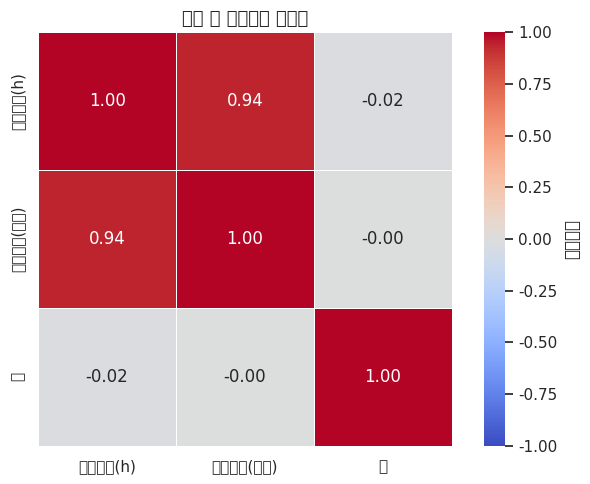

In [41]:
# 수치형 변수 간 상관계수
num_cols = ['정비시간(h)', '정비비용(만원)', '월']
corr = df[num_cols].corr()
print("[ 상관행렬 ]")
print(corr.round(2))

# 히트맵
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'label': '상관계수'})
plt.title('변수 간 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

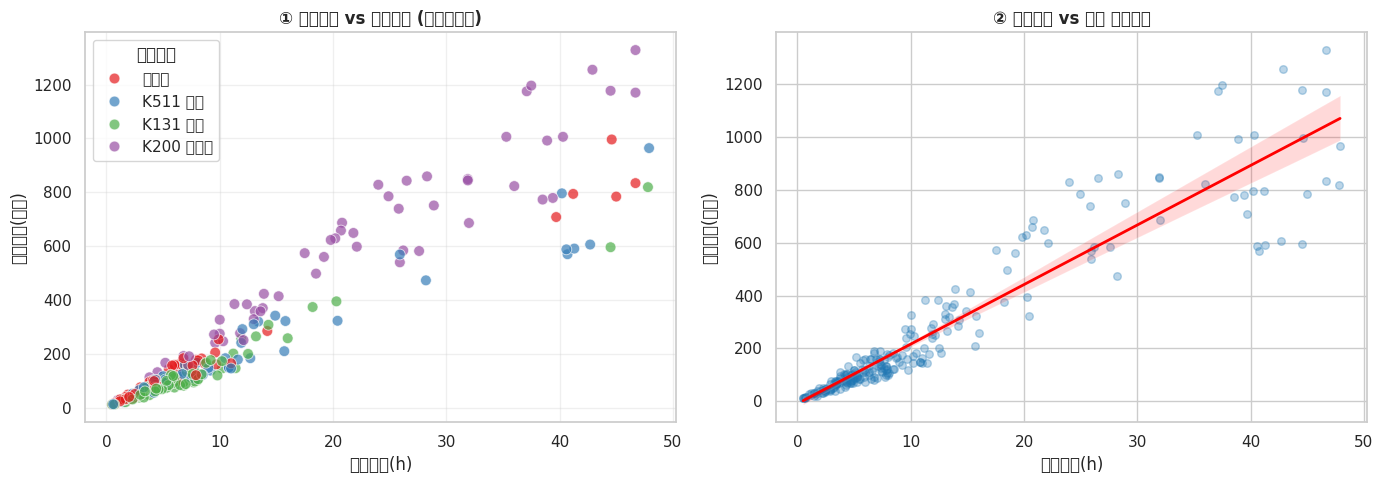

📊 정비시간 ↔ 정비비용: r=0.940, p=2.49e-112
   → **강한 양의 상관**
   → 정비시간이 길수록 비용도 비례하여 증가


In [42]:
# 산점도로 관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정비시간 vs 비용 (장비유형별 색상)
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.7, s=60,
                ax=axes[0])
axes[0].set_title('① 정비시간 vs 정비비용 (장비유형별)', fontweight='bold')
axes[0].grid(alpha=0.3)

# 회귀선 포함
sns.regplot(data=df, x='정비시간(h)', y='정비비용(만원)',
            scatter_kws={'alpha': 0.3, 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('② 정비시간 vs 비용 회귀분석', fontweight='bold')

plt.tight_layout()
plt.show()

# 상관계수 p-value
r, p = stats.pearsonr(df['정비시간(h)'], df['정비비용(만원)'])
print(f"📊 정비시간 ↔ 정비비용: r={r:.3f}, p={p:.2e}")
print(f"   → {'**강한 양의 상관**' if r >= 0.7 else '약한 양의 상관'}")
print(f"   → 정비시간이 길수록 비용도 비례하여 증가")

## 5-3. 피벗 테이블 + 히트맵 — 월 × 장비유형

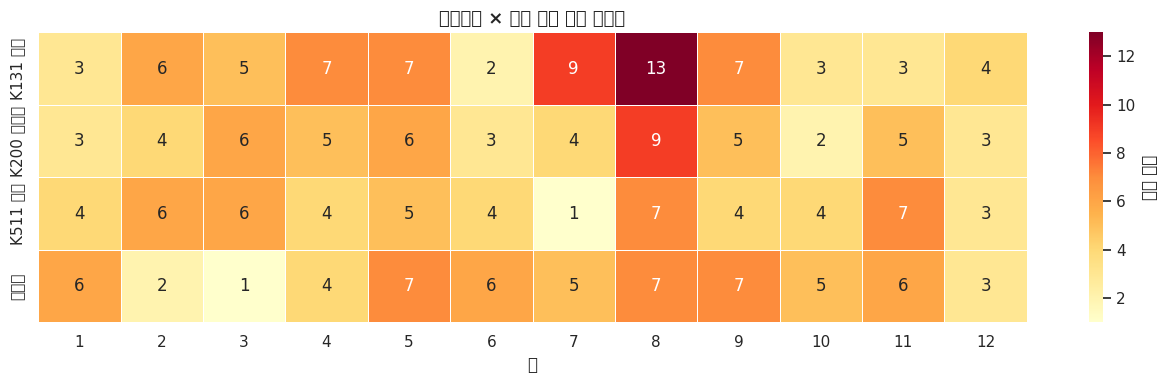

In [43]:
# 월×장비유형 정비 건수 피벗
pivot_cnt = pd.pivot_table(
    df, values='장비번호', index='장비유형',
    columns='월', aggfunc='count', fill_value=0
)

plt.figure(figsize=(13, 4))
sns.heatmap(pivot_cnt, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '정비 건수'})
plt.title('장비유형 × 월별 정비 건수 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('')
plt.tight_layout()
plt.show()

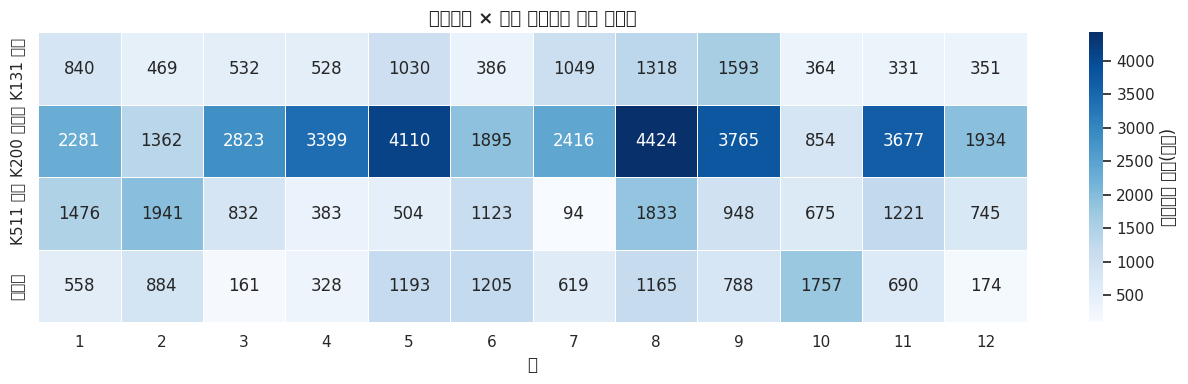


💡 최대 비용 지점: 8월 K200 장갑차 (4,424만원)


In [44]:
# 월×장비유형 정비비용 합계 피벗
pivot_cost = pd.pivot_table(
    df, values='정비비용(만원)', index='장비유형',
    columns='월', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(13, 4))
sns.heatmap(pivot_cost, annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': '정비비용 합계(만원)'})
plt.title('장비유형 × 월별 정비비용 합계 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('')
plt.tight_layout()
plt.show()

# 최대 비용 월·장비
max_val = pivot_cost.max().max()
max_loc = pivot_cost.stack().idxmax()
print(f"\n💡 최대 비용 지점: {max_loc[1]}월 {max_loc[0]} ({max_val:,.0f}만원)")

---
### 🔥 실습문제 5 - 다변량 분석
1. **담당부대별** 평균 정비시간과 비용 (`groupby` + `agg`)
2. **고장유형별** 정비비용 박스플롯 (`sns.boxplot`)
3. **장비유형 × 결과** 교차표 (`crosstab`) — 각 장비유형별 가동불능 비율 계산
4. **담당부대 × 장비유형** 정비 건수 피벗 + 히트맵

In [45]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

[ 1. 담당부대별 평균 ]
      평균시간   평균비용  건수
담당부대                 
1중대   12.9  292.6  74
2중대   14.3  315.5  53
3중대   11.6  246.2  55
4중대    9.7  198.4  56


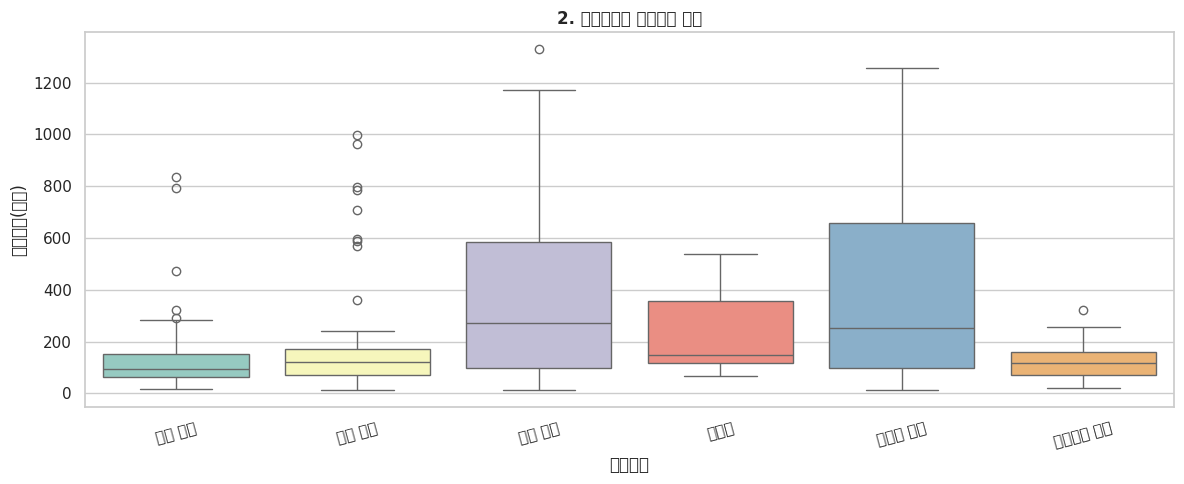


[ 3. 장비유형 × 결과 교차표 ]
결과        가동불능  부분완료  완료
장비유형                    
K131 트럭      8     9  52
K200 장갑차     2     4  49
K511 카고      2    11  42
발전기          6     7  46

[ 가동불능 비율 순위 ]
장비유형
K131 트럭     11.6
발전기         10.2
K200 장갑차     3.6
K511 카고      3.6
Name: 가동불능비율(%), dtype: float64


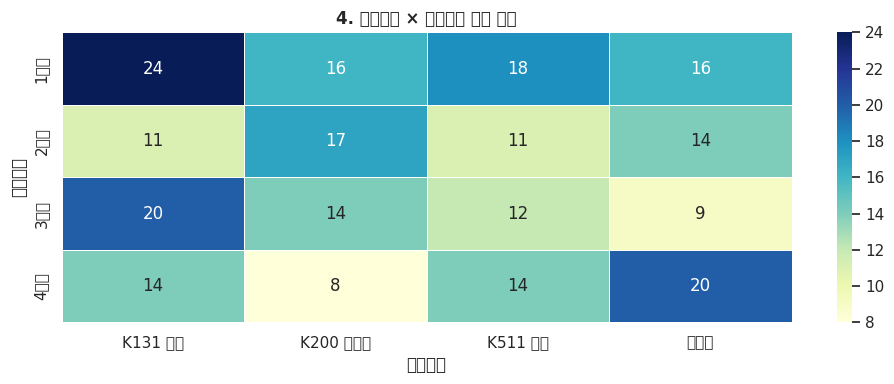

In [46]:
# 1) 담당부대별 평균 시간·비용
print("[ 1. 담당부대별 평균 ]")
unit_avg = df.groupby('담당부대').agg(
    평균시간 = ('정비시간(h)', 'mean'),
    평균비용 = ('정비비용(만원)', 'mean'),
    건수     = ('장비번호', 'count')
).round(1)
print(unit_avg)

# 2) 고장유형별 비용 박스플롯
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='고장유형', y='정비비용(만원)', palette='Set3')
plt.title('2. 고장유형별 정비비용 분포', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3) 장비유형 × 결과 교차표
print("\n[ 3. 장비유형 × 결과 교차표 ]")
ct = pd.crosstab(df['장비유형'], df['결과'])
print(ct)
# 가동불능 비율
ct['가동불능비율(%)'] = (ct['가동불능'] / ct.sum(axis=1) * 100).round(1)
print("\n[ 가동불능 비율 순위 ]")
print(ct['가동불능비율(%)'].sort_values(ascending=False))

# 4) 담당부대 × 장비유형 히트맵
plt.figure(figsize=(10, 4))
pv = pd.pivot_table(df, values='장비번호', index='담당부대',
                    columns='장비유형', aggfunc='count', fill_value=0)
sns.heatmap(pv, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('4. 담당부대 × 장비유형 정비 건수', fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🎨 Chapter 6. 어떤 차트를 선택할까? — 차트 선택 가이드

## 6-1. 6가지 차트 유형 & 용도

| 차트 | 언제? | 예시 |
|---|---|---|
| 📊 **막대 차트** | 범주 간 크기 비교 | 장비별 건수 |
| 📈 **선 그래프** | 시간에 따른 변화·추세 | 월별 고장 추이 |
| 📉 **히스토그램** | 수치형 변수의 **분포** | 정비시간 분포 |
| 📦 **박스플롯** | **이상치 탐지** + 그룹 비교 | 장비별 비용 분포 |
| 🌡 **히트맵** | **상관관계** · 교차표 시각화 | 변수 간 상관 |
| 🔵 **산점도** | 두 변수 관계 · 군집 파악 | 시간 vs 비용 |

## ⚠️ 주의사항
- **파이 차트**는 범주 **6개 이상** 이면 오히려 읽기 어려움 → **막대 차트** 대체 권장
- **선 그래프**는 X축이 반드시 **시간 순서** 일 때만 사용!

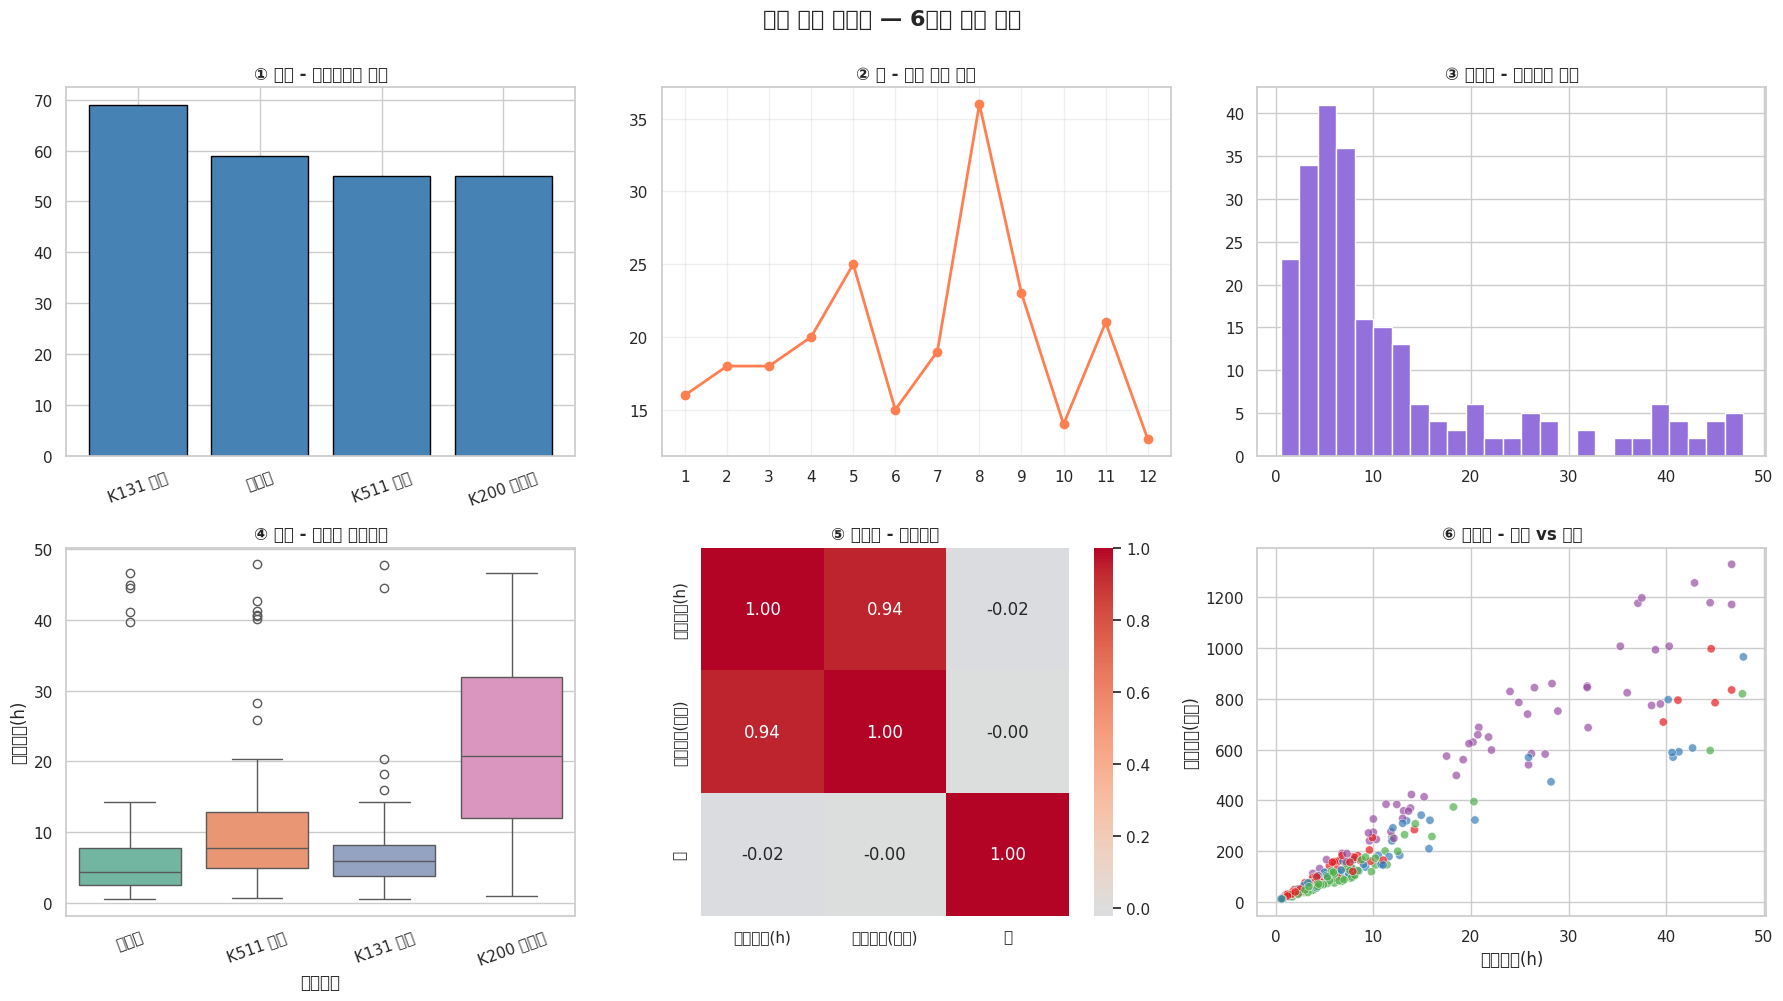

In [47]:
# 6가지 차트를 한 Figure에 비교
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('차트 선택 가이드 — 6가지 대표 차트', fontsize=16, fontweight='bold', y=1.00)

# ① 막대 차트 - 장비별 건수
eq_cnt = df['장비유형'].value_counts()
axes[0,0].bar(eq_cnt.index, eq_cnt.values,
              color='steelblue', edgecolor='black')
axes[0,0].set_title('① 막대 - 장비유형별 건수', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=20)

# ② 선 그래프 - 월별 추이
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='coral', linewidth=2)
axes[0,1].set_title('② 선 - 월별 건수 추이', fontweight='bold')
axes[0,1].set_xticks(range(1,13))
axes[0,1].grid(alpha=0.3)

# ③ 히스토그램 - 시간 분포
axes[0,2].hist(df['정비시간(h)'], bins=25, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('③ 히스토 - 정비시간 분포', fontweight='bold')

# ④ 박스플롯 - 장비별 시간
sns.boxplot(data=df, x='장비유형', y='정비시간(h)',
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('④ 박스 - 장비별 정비시간', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# ⑤ 히트맵 - 상관
sns.heatmap(df[['정비시간(h)','정비비용(만원)','월']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1,1])
axes[1,1].set_title('⑤ 히트맵 - 상관관계', fontweight='bold')

# ⑥ 산점도 - 시간 vs 비용
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.7,
                ax=axes[1,2], legend=False)
axes[1,2].set_title('⑥ 산점도 - 시간 vs 비용', fontweight='bold')

plt.tight_layout()
plt.show()

---
### 🔥 실습문제 6 - 차트 선택
다음 상황에서 가장 적절한 차트를 선택하세요.

1. 부대별 연간 정비비용 **총액** 을 한눈에 비교 → ?
2. **정비시간의 분포 모양**을 확인 → ?
3. 월별 가동불능 건수 **변화 추이** → ?
4. **정비시간 이상치** 존재 여부 확인 → ?
5. **정비시간과 비용의 관계** → ?
6. 장비유형×월 **정비건수 패턴** → ?

In [48]:
# ✍️ 답을 작성하세요 (막대/선/히스토/박스/히트맵/산점도 중 선택)

answer_1 = ""
answer_2 = ""
answer_3 = ""
answer_4 = ""
answer_5 = ""
answer_6 = ""

print(f"1) 부대별 비용 총액 비교   → {answer_1}")
print(f"2) 정비시간 분포 모양      → {answer_2}")
print(f"3) 월별 가동불능 추이      → {answer_3}")
print(f"4) 정비시간 이상치 확인    → {answer_4}")
print(f"5) 시간과 비용 관계        → {answer_5}")
print(f"6) 장비×월 패턴            → {answer_6}")

1) 부대별 비용 총액 비교   → 
2) 정비시간 분포 모양      → 
3) 월별 가동불능 추이      → 
4) 정비시간 이상치 확인    → 
5) 시간과 비용 관계        → 
6) 장비×월 패턴            → 


**✅ 정답**

In [49]:
answer_1 = "막대 차트"       # 범주 간 크기 비교
answer_2 = "히스토그램"        # 수치 분포
answer_3 = "선 그래프"         # 시간 추이
answer_4 = "박스플롯"          # 이상치 탐지
answer_5 = "산점도"            # 두 변수 관계
answer_6 = "히트맵"            # 교차 패턴

print(f"1) 부대별 비용 총액 비교   → {answer_1}   (범주 비교)")
print(f"2) 정비시간 분포 모양      → {answer_2}    (수치 분포)")
print(f"3) 월별 가동불능 추이      → {answer_3}    (시간 추이)")
print(f"4) 정비시간 이상치 확인    → {answer_4}     (이상치 탐지)")
print(f"5) 시간과 비용 관계        → {answer_5}       (두 변수 관계)")
print(f"6) 장비×월 패턴            → {answer_6}       (교차표)")

1) 부대별 비용 총액 비교   → 막대 차트   (범주 비교)
2) 정비시간 분포 모양      → 히스토그램    (수치 분포)
3) 월별 가동불능 추이      → 선 그래프    (시간 추이)
4) 정비시간 이상치 확인    → 박스플롯     (이상치 탐지)
5) 시간과 비용 관계        → 산점도       (두 변수 관계)
6) 장비×월 패턴            → 히트맵       (교차표)


---
# 💡 Chapter 7. [Step 6] 인사이트 도출 및 보고

> **EDA의 최종 단계**: 분석 결과를 **의사결정 권고안** 으로 연결  
> 숫자·차트 → **행동 가능한 결론** 으로 변환

## 7-1. 인사이트 1 — 장비유형별 집중 관리 대상

In [50]:
# 장비유형별 총 비용과 건수
equip_summary = df.groupby('장비유형').agg(
    정비건수 = ('장비번호', 'count'),
    총비용   = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean'),
    가동불능 = ('결과', lambda x: (x == '가동불능').sum())
).round(1).sort_values('총비용', ascending=False)

equip_summary['비용비율(%)'] = (equip_summary['총비용'] / equip_summary['총비용'].sum() * 100).round(1)

print("🎯 장비유형별 정비 현황")
print(equip_summary)

# 최고 비용 장비
top_equip = equip_summary.index[0]
top_pct = equip_summary.iloc[0]['비용비율(%)']
print(f"\n💡 인사이트 1: {top_equip}이(가) 전체 정비비용의 {top_pct}% 차지")
print(f"   → 집중 관리 대상")

🎯 장비유형별 정비 현황
          정비건수    총비용  평균시간  가동불능  비용비율(%)
장비유형                                      
K200 장갑차    55  32940  22.1     2     52.3
K511 카고     55  11775  12.2     2     18.7
발전기         59   9522   8.1     6     15.1
K131 트럭     69   8791   7.7     8     13.9

💡 인사이트 1: K200 장갑차이(가) 전체 정비비용의 52.3% 차지
   → 집중 관리 대상


## 7-2. 인사이트 2 — 계절성 (월별 비용 패턴)

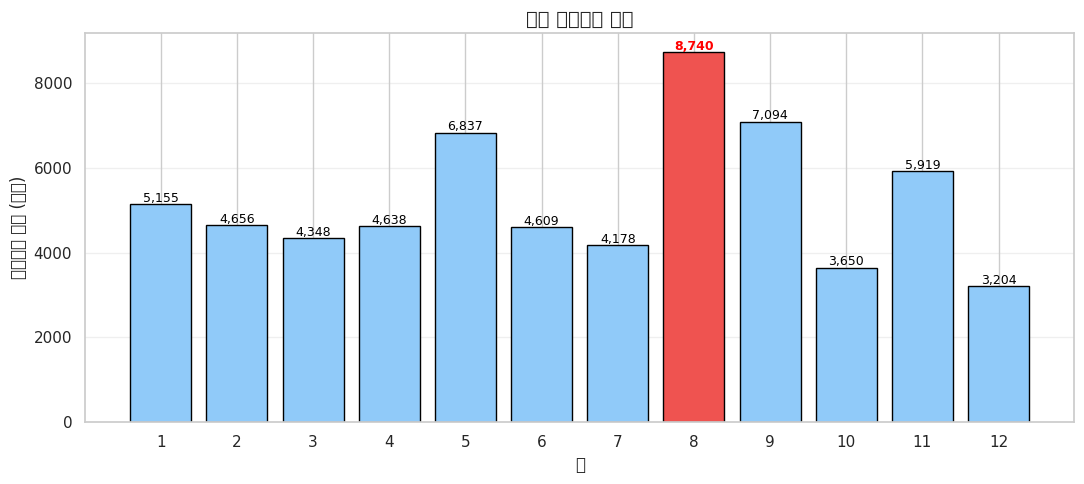

💡 인사이트 2: 8월 비용 최고점 (8,740만원)
   → 3분기(7-9월, 하계 훈련기) 비용 비율: 31.8%
   → 7월 훈련 前 사전 정비 계획 수립 권고


In [51]:
# 월별 총 정비비용
monthly_cost = df.groupby('월')['정비비용(만원)'].sum()

plt.figure(figsize=(11, 5))
bars = plt.bar(monthly_cost.index, monthly_cost.values,
               color=['#90CAF9']*7 + ['#EF5350'] + ['#90CAF9']*4,
               edgecolor='black')

# 최대값 강조
peak = monthly_cost.idxmax()
peak_val = monthly_cost.max()
for i, (m, v) in enumerate(monthly_cost.items()):
    plt.text(m, v + 50, f'{v:,.0f}', ha='center',
             fontsize=9, fontweight='bold' if m == peak else 'normal',
             color='red' if m == peak else 'black')

plt.title('월별 정비비용 합계', fontsize=14, fontweight='bold')
plt.xlabel('월'); plt.ylabel('정비비용 합계 (만원)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 인사이트
Q3_cost = df[df['분기'] == 3]['정비비용(만원)'].sum()
total_cost = df['정비비용(만원)'].sum()
q3_pct = Q3_cost / total_cost * 100

print(f"💡 인사이트 2: {peak}월 비용 최고점 ({peak_val:,}만원)")
print(f"   → 3분기(7-9월, 하계 훈련기) 비용 비율: {q3_pct:.1f}%")
print(f"   → 7월 훈련 前 사전 정비 계획 수립 권고")

## 7-3. 인사이트 3 — 반복 고장 장비

In [52]:
# 반복 고장 장비 TOP 5
repeat = df['장비번호'].value_counts().head(5)
print("🔄 반복 고장 장비 TOP 5")
print(repeat)

# 해당 장비의 고장 내역
top_unit = repeat.index[0]
top_history = df[df['장비번호'] == top_unit].sort_values('정비일자')
print(f"\n🔍 {top_unit}의 고장 내역:")
print(top_history[['정비일자', '고장유형', '정비시간(h)', '정비비용(만원)', '결과']].to_string(index=False))

total_cost_repeat = top_history['정비비용(만원)'].sum()
print(f"\n💡 인사이트 3: {top_unit}의 연간 정비 횟수 {len(top_history)}회, 누적 비용 {total_cost_repeat}만원")
print(f"   → 해당 장비 교체 또는 정밀 점검 필요")

🔄 반복 고장 장비 TOP 5
장비번호
K131-023    5
GEN-006     5
K131-025    5
K131-015    5
K131-001    5
Name: count, dtype: int64

🔍 K131-023의 고장 내역:
      정비일자   고장유형  정비시간(h)  정비비용(만원) 결과
2024-02-20  오일 누유      8.0       101 완료
2024-03-03  오일 누유     11.2       201 완료
2024-07-23  궤도 마모     20.3       395 완료
2024-08-18  엔진 이상      5.3       100 완료
2024-09-11 변속기 결함     47.8       819 완료

💡 인사이트 3: K131-023의 연간 정비 횟수 5회, 누적 비용 1616만원
   → 해당 장비 교체 또는 정밀 점검 필요


## 7-4. 인사이트 4 — 가동불능 분석

⚠️ 가동불능 건수: 18건 (전체의 7.6%)

[ 가동불능 원인별 분포 ]
고장유형
궤도 마모      5
오일 누유      4
변속기 결함     3
브레이크 마모    3
엔진 이상      3
Name: count, dtype: int64


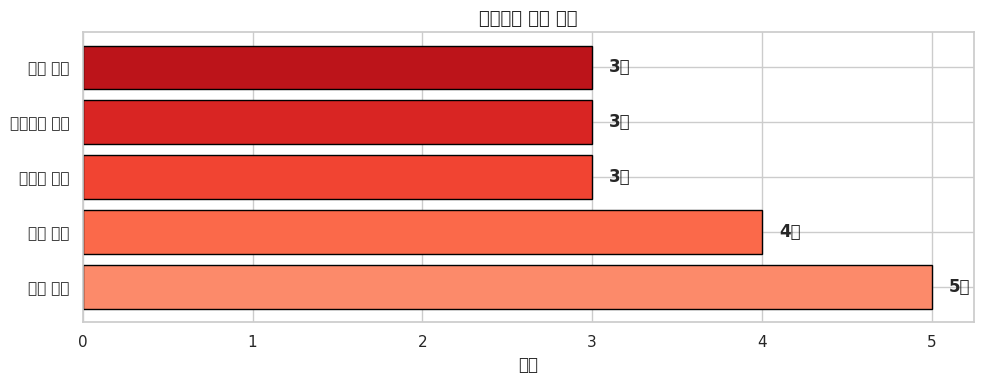


💡 인사이트 4: 가동불능의 주요 원인은 '궤도 마모' (5건)
   → 해당 부품의 여분 보유량 증가 검토


In [53]:
# 가동불능 사례 분석
downtime = df[df['결과'] == '가동불능']
print(f"⚠️ 가동불능 건수: {len(downtime)}건 (전체의 {len(downtime)/len(df)*100:.1f}%)")

# 고장유형별 가동불능 분포
dt_by_type = downtime['고장유형'].value_counts()
print(f"\n[ 가동불능 원인별 분포 ]")
print(dt_by_type)

# 시각화
plt.figure(figsize=(10, 4))
colors_dt = plt.cm.Reds(np.linspace(0.4, 0.8, len(dt_by_type)))
bars = plt.barh(dt_by_type.index, dt_by_type.values,
                color=colors_dt, edgecolor='black')
for bar, v in zip(bars, dt_by_type.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{v}건', va='center', fontweight='bold')
plt.title('가동불능 원인 분포', fontsize=13, fontweight='bold')
plt.xlabel('건수')
plt.tight_layout()
plt.show()

main_cause = dt_by_type.idxmax()
print(f"\n💡 인사이트 4: 가동불능의 주요 원인은 '{main_cause}' ({dt_by_type.max()}건)")
print(f"   → 해당 부품의 여분 보유량 증가 검토")

---
# 🏆 Chapter 8. 종합 대시보드 + 최종 보고서

> 지금까지 분석한 내용을 **하나의 Figure** 와 **텍스트 보고서** 로 정리합니다.  
> 4일차 미니 프로젝트의 **최종 산출물**입니다.

## 8-1. 6종 차트 종합 대시보드

✅ /content/EDA_dashboard.png 저장 완료


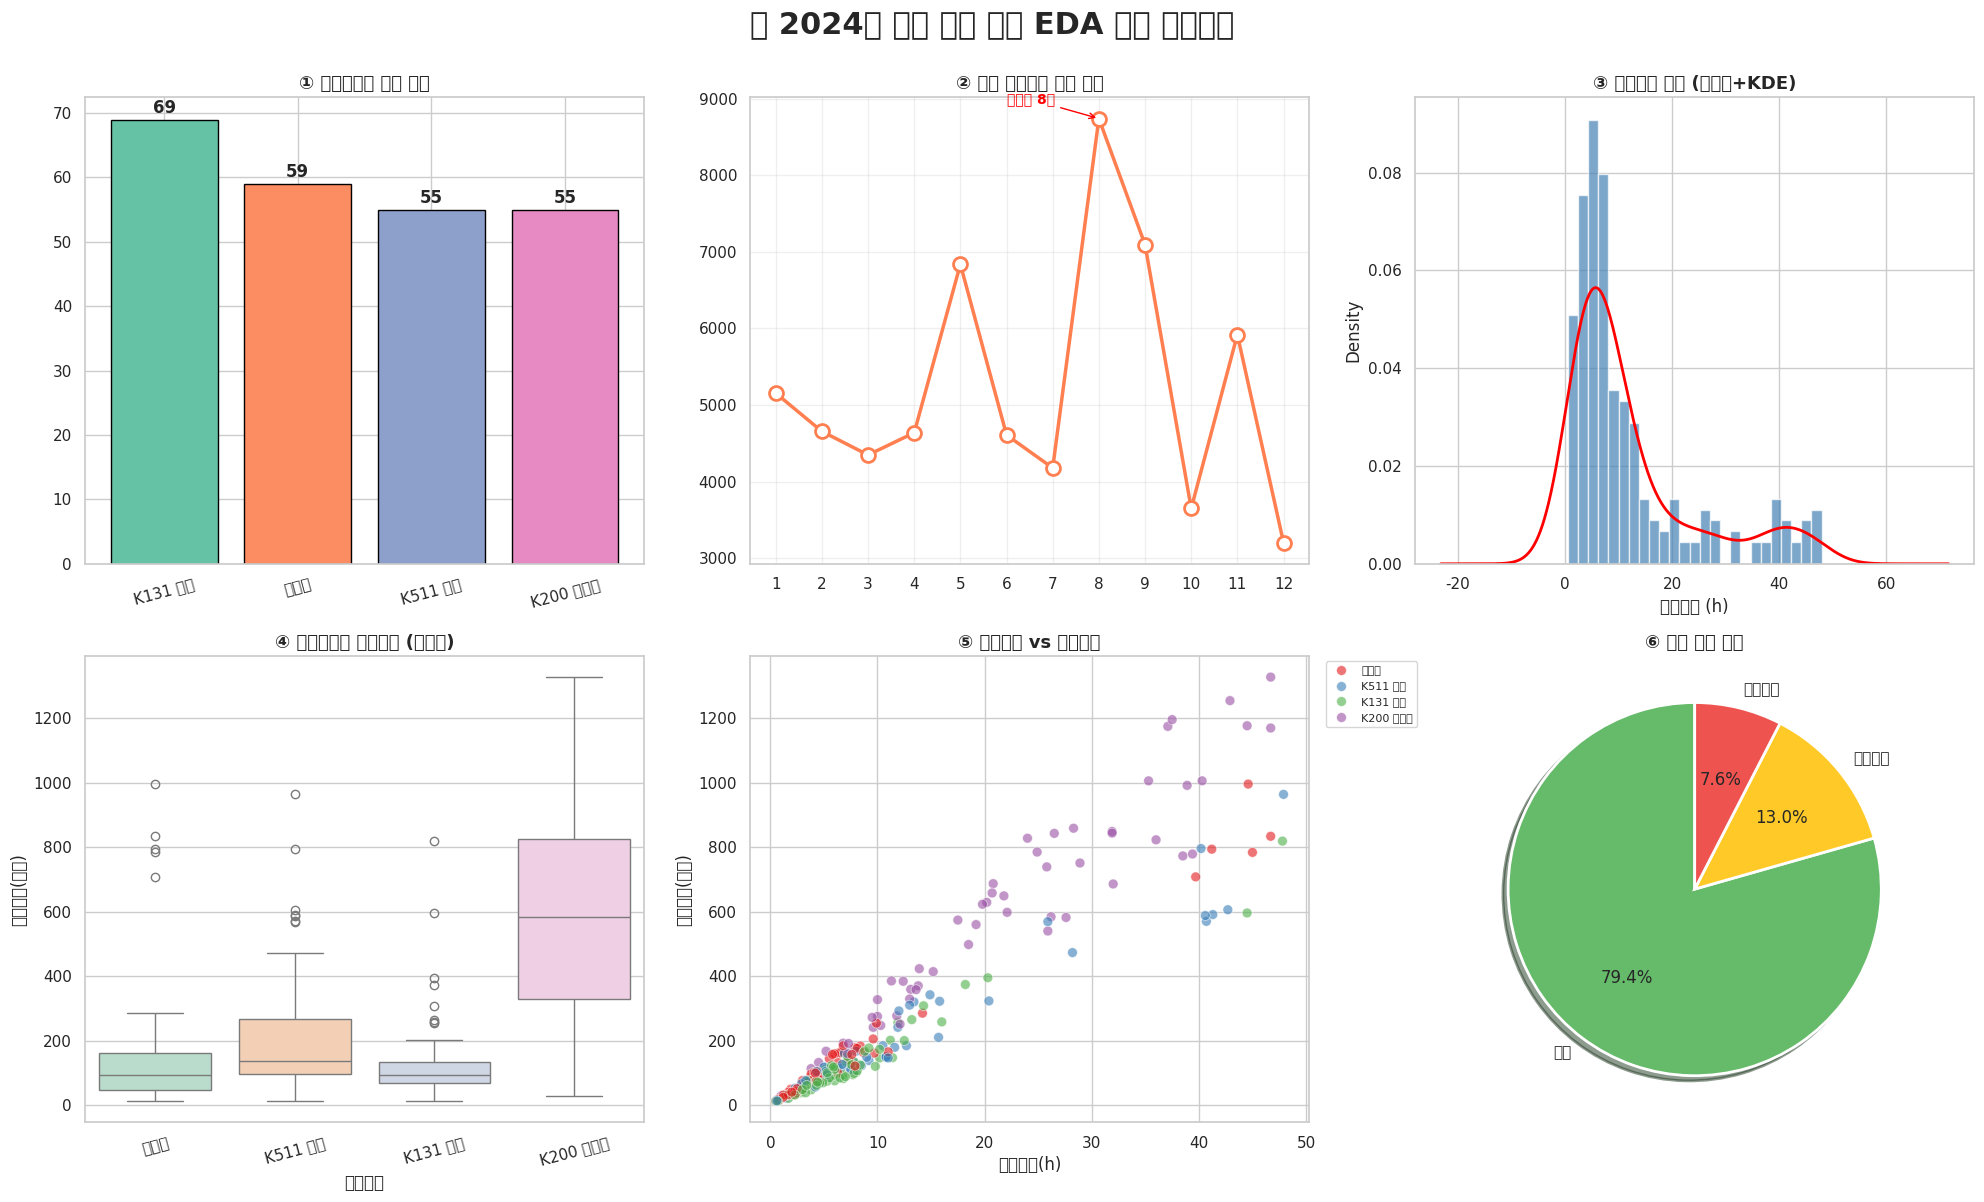

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🎖️ 2024년 부대 장비 정비 EDA 종합 대시보드',
             fontsize=22, fontweight='bold', y=1.00)

# ① 장비유형별 정비 건수
eq_cnt = df['장비유형'].value_counts()
colors_eq = sns.color_palette('Set2', len(eq_cnt))
bars1 = axes[0,0].bar(eq_cnt.index, eq_cnt.values, color=colors_eq, edgecolor='black')
for bar, v in zip(bars1, eq_cnt.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   str(v), ha='center', fontweight='bold')
axes[0,0].set_title('① 장비유형별 정비 건수', fontsize=13, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=15)

# ② 월별 정비비용 합계 추이
mc = df.groupby('월')['정비비용(만원)'].sum().reindex(range(1,13), fill_value=0)
axes[0,1].plot(mc.index, mc.values, marker='o', color='coral',
               linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2)
peak_m = mc.idxmax()
axes[0,1].annotate(f'최고점 {peak_m}월',
                   xy=(peak_m, mc.max()), xytext=(peak_m-2, mc.max()+200),
                   fontsize=10, fontweight='bold', color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
axes[0,1].set_title('② 월별 정비비용 합계 추이', fontsize=13, fontweight='bold')
axes[0,1].set_xticks(range(1,13))
axes[0,1].grid(alpha=0.3)

# ③ 정비시간 분포 (히스토그램)
axes[0,2].hist(df['정비시간(h)'], bins=25, color='steelblue',
               edgecolor='white', density=True, alpha=0.7)
df['정비시간(h)'].plot(kind='kde', ax=axes[0,2], color='red', linewidth=2)
axes[0,2].set_title('③ 정비시간 분포 (히스토+KDE)', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('정비시간 (h)')

# ④ 장비유형별 비용 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비비용(만원)',
            palette='Pastel2', ax=axes[1,0])
axes[1,0].set_title('④ 장비유형별 정비비용 (이상치)', fontsize=13, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# ⑤ 시간 vs 비용 산점도
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.6, s=50,
                ax=axes[1,1])
axes[1,1].set_title('⑤ 정비시간 vs 정비비용', fontsize=13, fontweight='bold')
axes[1,1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# ⑥ 결과 분포 파이 차트
rc = df['결과'].value_counts()
axes[1,2].pie(rc, labels=rc.index, autopct='%1.1f%%',
              startangle=90, colors=['#66BB6A','#FFCA28','#EF5350'],
              shadow=True, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,2].set_title('⑥ 정비 결과 분포', fontsize=13, fontweight='bold')

plt.tight_layout()

# PNG로 저장
plt.savefig('/content/EDA_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("✅ /content/EDA_dashboard.png 저장 완료")
plt.show()

## 8-2. 최종 보고서 자동 생성

In [55]:
print("=" * 60)
print("📋 2024년 부대 장비 정비 EDA 분석 보고서")
print("=" * 60)

# ── 1. 개요 ──
print(f"\n【 1. 분석 개요 】")
print(f"  • 분석 기간    : 2024-01 ~ 2024-12 (12개월)")
print(f"  • 총 정비 건수 : {len(df):,}건")
print(f"  • 총 정비비용  : {df['정비비용(만원)'].sum():,}만원")
print(f"  • 평균 정비시간: {df['정비시간(h)'].mean():.2f}시간")
print(f"  • 가동불능율   : {(df['결과']=='가동불능').mean()*100:.1f}%")

# ── 2. 주요 발견 ──
print(f"\n【 2. 주요 발견 】")

# 발견 1: 고비용 장비
top_eq = df.groupby('장비유형')['정비비용(만원)'].sum().sort_values(ascending=False)
print(f"  [발견 1] 최고비용 장비: {top_eq.index[0]}")
print(f"           → 총 {top_eq.iloc[0]:,}만원 (전체의 {top_eq.iloc[0]/top_eq.sum()*100:.1f}%)")

# 발견 2: 정비 집중월
peak_m = df.groupby('월').size().idxmax()
peak_cnt = df.groupby('월').size().max()
print(f"\n  [발견 2] 최다 정비월: {peak_m}월 ({peak_cnt}건)")
print(f"           → 하계 훈련(6~8월) 직후 누적 손모 원인 추정")

# 발견 3: 강한 상관
r, p = stats.pearsonr(df['정비시간(h)'], df['정비비용(만원)'])
print(f"\n  [발견 3] 정비시간 ↔ 비용 상관계수: r={r:.3f} (강한 양의 상관)")
print(f"           → 시간 단축 = 비용 절감 효과")

# 발견 4: 반복 고장
repeat = df['장비번호'].value_counts()
repeat_3plus = (repeat >= 3).sum()
print(f"\n  [발견 4] 연 3회 이상 정비 장비: {repeat_3plus}대")
print(f"           → 교체 또는 정밀 점검 대상")

# ── 3. 권고사항 ──
print(f"\n【 3. 의사결정 권고안 】")
print(f"  ① {top_eq.index[0]} 전용 예방정비 프로그램 수립")
print(f"     → 월 1회 정기 점검, 부품 사전 확보")
print(f"  ② 7월 이전 사전 정비 계획 수립")
print(f"     → 하계 훈련 前 주요 장비 종합 점검")
print(f"  ③ 반복 고장 장비 {repeat_3plus}대 긴급 점검")
print(f"     → 노후 부품 교체 또는 장비 교체")
print(f"  ④ 가동불능 주요 원인 부품 여분 확보")

print("\n" + "=" * 60)
print(f"  📅 보고일: {pd.Timestamp.today().strftime('%Y-%m-%d')}")
print(f"  📂 대시보드: /content/EDA_dashboard.png")
print("=" * 60)

📋 2024년 부대 장비 정비 EDA 분석 보고서

【 1. 분석 개요 】
  • 분석 기간    : 2024-01 ~ 2024-12 (12개월)
  • 총 정비 건수 : 238건
  • 총 정비비용  : 63,028만원
  • 평균 정비시간: 12.15시간
  • 가동불능율   : 7.6%

【 2. 주요 발견 】
  [발견 1] 최고비용 장비: K200 장갑차
           → 총 32,940만원 (전체의 52.3%)

  [발견 2] 최다 정비월: 8월 (36건)
           → 하계 훈련(6~8월) 직후 누적 손모 원인 추정

  [발견 3] 정비시간 ↔ 비용 상관계수: r=0.940 (강한 양의 상관)
           → 시간 단축 = 비용 절감 효과

  [발견 4] 연 3회 이상 정비 장비: 42대
           → 교체 또는 정밀 점검 대상

【 3. 의사결정 권고안 】
  ① K200 장갑차 전용 예방정비 프로그램 수립
     → 월 1회 정기 점검, 부품 사전 확보
  ② 7월 이전 사전 정비 계획 수립
     → 하계 훈련 前 주요 장비 종합 점검
  ③ 반복 고장 장비 42대 긴급 점검
     → 노후 부품 교체 또는 장비 교체
  ④ 가동불능 주요 원인 부품 여분 확보

  📅 보고일: 2026-04-29
  📂 대시보드: /content/EDA_dashboard.png


## 8-3. 분석 결과를 CSV로 저장

In [56]:
# 핵심 요약 표 저장
equip_final = df.groupby('장비유형').agg(
    정비건수 = ('장비번호', 'count'),
    총비용   = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean'),
    가동불능 = ('결과', lambda x: (x == '가동불능').sum())
).round(2).sort_values('총비용', ascending=False)

equip_final.to_csv('/content/EDA_summary.csv', encoding='utf-8-sig')

# 월별 추이 저장
monthly_summary = df.groupby('월').agg(
    건수 = ('장비번호', 'count'),
    총비용 = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean')
).round(2)
monthly_summary.to_csv('/content/EDA_monthly.csv', encoding='utf-8-sig')

print("✅ 저장 완료")
print("  - /content/EDA_summary.csv  (장비유형 요약)")
print("  - /content/EDA_monthly.csv  (월별 추이)")
print("  - /content/EDA_dashboard.png (종합 대시보드)")

✅ 저장 완료
  - /content/EDA_summary.csv  (장비유형 요약)
  - /content/EDA_monthly.csv  (월별 추이)
  - /content/EDA_dashboard.png (종합 대시보드)


---
# 🚀 Chapter 9. 스스로 해보는 미니 프로젝트

> 지금까지 배운 6단계 EDA를 **다른 주제** 로 직접 실행해 보세요.  
> 막히면 **Vibe Coding(ChatGPT/Claude)** 을 활용해 보세요!

## 🎯 미션: 담당부대 관점의 EDA
지금까지는 **장비유형** 관점에서 분석했습니다. 이제 **담당부대** 관점에서 다시 분석하세요.

### 요구사항
1. **담당부대별 정비 건수와 총 비용** 순위 (막대그래프)
2. **부대 × 장비유형 피벗 테이블** (정비 건수) + 히트맵
3. **부대별 월 추이** (4개 부대의 월별 정비 건수 선 그래프)
4. **부대별 가동불능률** 계산 및 비교
5. **한 줄 인사이트** 3개 이상 도출 (print 문으로)

In [57]:
# ✍️ 여기에 본인만의 EDA 분석을 작성하세요
# 힌트: df는 이미 로드되어 있습니다. 아래 3-4개의 그룹화/피벗/시각화 조합으로 시작하세요.

# 1) 담당부대별 정비 건수와 총 비용

# 2) 부대 × 장비유형 피벗

# 3) 부대별 월 추이

# 4) 부대별 가동불능률

# 5) 인사이트 출력


**✅ 샘플 솔루션**

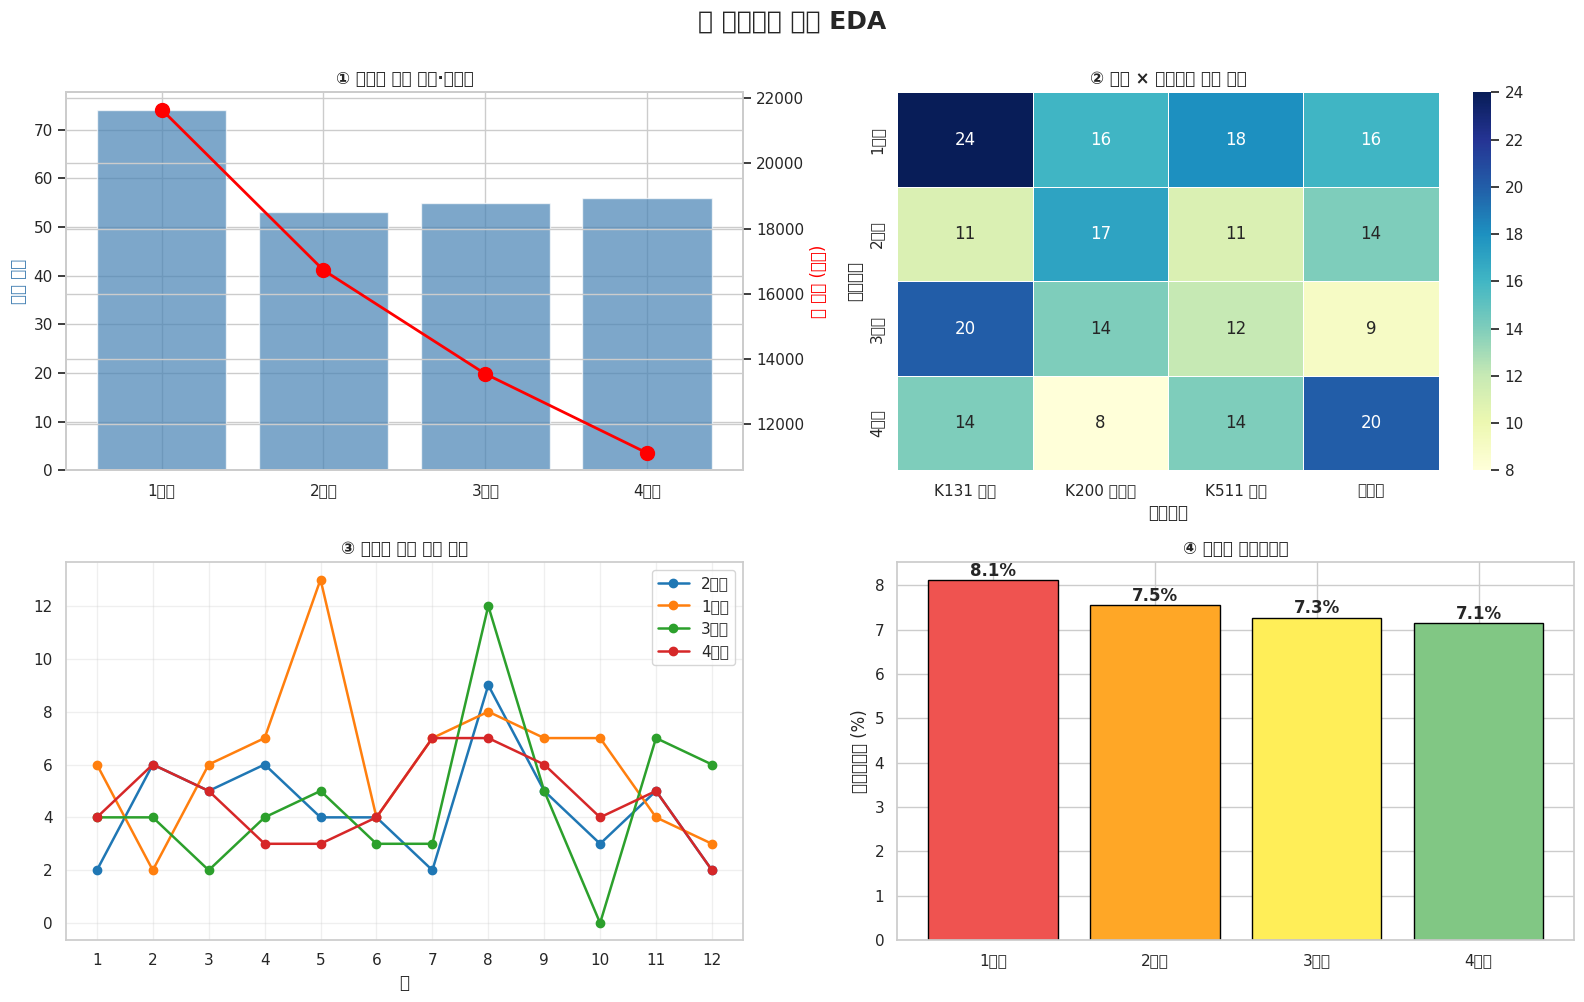


💡 담당부대 관점 인사이트
① 정비비용 최다 부대: 1중대 (21,652만원)
   → 장비 노후화 또는 사용 강도 조사 필요

② 가동불능률 최다: 1중대 (8.1%)
   → 장비 관리 체계 개선 권고

③ 전체 8월 정비 집중
   → 모든 부대에 사전 정비 가이드 배포


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📊 담당부대 관점 EDA', fontsize=18, fontweight='bold', y=1.00)

# 1) 부대별 정비 건수와 총 비용
unit_stat = df.groupby('담당부대').agg(
    건수 = ('장비번호', 'count'),
    총비용 = ('정비비용(만원)', 'sum')
).sort_values('총비용', ascending=False)

ax = axes[0,0]
ax2 = ax.twinx()
x = range(len(unit_stat))
ax.bar(x, unit_stat['건수'], color='steelblue', alpha=0.7, label='건수')
ax2.plot(x, unit_stat['총비용'], marker='o', color='red', linewidth=2, markersize=10, label='총비용')
ax.set_xticks(x); ax.set_xticklabels(unit_stat.index)
ax.set_ylabel('정비 건수', color='steelblue')
ax2.set_ylabel('총 비용 (만원)', color='red')
ax.set_title('① 부대별 정비 건수·총비용', fontweight='bold')

# 2) 부대 × 장비유형 피벗 히트맵
pv = pd.pivot_table(df, values='장비번호', index='담당부대',
                    columns='장비유형', aggfunc='count', fill_value=0)
sns.heatmap(pv, annot=True, fmt='d', cmap='YlGnBu',
            linewidths=0.5, ax=axes[0,1])
axes[0,1].set_title('② 부대 × 장비유형 정비 건수', fontweight='bold')

# 3) 부대별 월 추이
for unit in df['담당부대'].unique():
    unit_monthly = df[df['담당부대']==unit].groupby('월').size().reindex(range(1,13), fill_value=0)
    axes[1,0].plot(unit_monthly.index, unit_monthly.values,
                   marker='o', linewidth=1.8, label=unit)
axes[1,0].set_title('③ 부대별 월별 정비 건수', fontweight='bold')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xlabel('월'); axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# 4) 부대별 가동불능률
down_rate = df.groupby('담당부대').apply(
    lambda g: (g['결과']=='가동불능').mean() * 100
).sort_values(ascending=False).round(2)
bars = axes[1,1].bar(down_rate.index, down_rate.values,
                     color=['#EF5350','#FFA726','#FFEE58','#81C784'], edgecolor='black')
for bar, v in zip(bars, down_rate.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('④ 부대별 가동불능률', fontweight='bold')
axes[1,1].set_ylabel('가동불능률 (%)')

plt.tight_layout()
plt.show()

# 5) 인사이트
print("\n" + "=" * 50)
print("💡 담당부대 관점 인사이트")
print("=" * 50)
worst_unit = unit_stat.index[0]
print(f"① 정비비용 최다 부대: {worst_unit} ({unit_stat.iloc[0]['총비용']:,}만원)")
print(f"   → 장비 노후화 또는 사용 강도 조사 필요")

high_down = down_rate.idxmax()
print(f"\n② 가동불능률 최다: {high_down} ({down_rate.max():.1f}%)")
print(f"   → 장비 관리 체계 개선 권고")

busy_month = df.groupby('월').size().idxmax()
print(f"\n③ 전체 {busy_month}월 정비 집중")
print(f"   → 모든 부대에 사전 정비 가이드 배포")

---
# 🎓 4일차 & 30시간 전체 교육 수료 정리

## ✅ 4일차 배운 내용
| 단계 | 도구 | 결과물 |
|---|---|---|
| **1. 데이터 로드** | `read_csv`, `info`, `shape` | 데이터 구조 파악 |
| **2. 품질 점검** | `isnull`, `dropna`, `fillna` | 깨끗한 데이터 |
| **3. 기술통계** | `describe`, `value_counts`, IQR | 분포 요약 |
| **4. 단변량 분석** | 히스토그램, 박스플롯 | 개별 변수 특성 |
| **5. 다변량 분석** | `groupby`, `corr`, 히트맵 | 변수 간 관계 |
| **6. 인사이트** | 자동 보고서 + 대시보드 | **의사결정 권고** |

## 🏆 30시간 전체 수료 한눈에 보기
| 일차 | 주제 | 핵심 기술 |
|---|---|---|
| **1일차** | 파이썬 기초 & Colab | 변수·조건문·라이브러리·Vibe Coding |
| **2일차** | 데이터 수집 & 전처리 | pandas, 결측치·이상치·정규화 |
| **3일차** | 데이터 분석 & 가공 | groupby·pivot·corr·시각화 |
| **4일차** | EDA 미니 프로젝트 | 종합 분석 파이프라인 |

## 💡 John Tukey의 마지막 메시지
> **"데이터를 먼저 이해하고, 그 다음 분석하라."**  
> EDA는 분석의 시작이자, **의사결정의 근거**를 만드는 과정입니다.

## 🚀 수료 후 자기계발 로드맵
| Lv | 단계 | 추천 |
|---|---|---|
| 1 | **기초 유지** | 오늘 코드를 본인 부대 데이터에 적용 |
| 2 | **통계 강화** | 통계학 기초, 가설검정 |
| 3 | **ML 입문** | scikit-learn, 분류·회귀 모델 |
| 4 | **딥러닝** | PyTorch, TensorFlow |
| 5 | **AI 자동화** | API 활용, 업무 자동화 파이프라인 |

### 📚 추천 학습 자원
- **KMOOC** — 무료 온라인 강좌
- **유튜브 "모두의 AI"** — 한국어 AI 튜토리얼
- **Anthropic Claude** — 코딩·분석 AI 어시스턴트
- **Kaggle** — 실전 데이터 분석 프로젝트

---

### ⚠️ AI 활용 시 반드시 지켜야 할 수칙
- 🚫 **군사기밀·개인정보 입력 금지**
- 🔍 **AI 결과 반드시 검증** (맹신 금지)
- 📄 **저작권 및 보안 유의**
- ✅ **최종 책임은 사용자** — AI는 도구

---

## 🎖️ 수료를 축하합니다!

> **"스마트 강군 육성, 국방 AX(AI 전환)에 만전을 기하겠습니다"**

오늘 배운 EDA 기술을 본인 부대 실무 데이터에 적용하여  
**데이터 기반 의사결정 문화**를 만들어가세요!

---

*교육기관: (사)한국오픈소스협회 | 문의: 02-6012-7414 / kmil@osskorea.org*